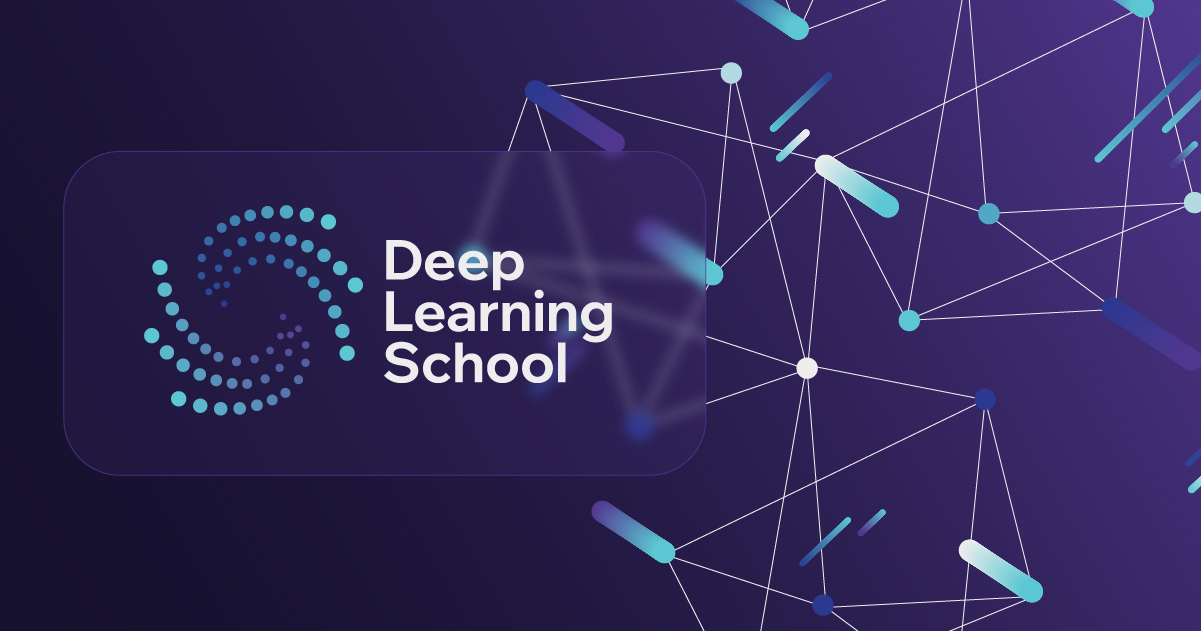


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [28]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [29]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: /kaggle/input/lfw-dataset


In [30]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: /kaggle/input/lfw-attributes


In [31]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

Данные успешно загружены!
Форма images: (13143, 45, 45, 3)
Форма attrs: (13143, 73)

Типы данных в атрибутах:
float64    73
Name: count, dtype: int64

Размер обучающей выборки: 10514 изображений
Размер валидационной выборки: 2629 изображений


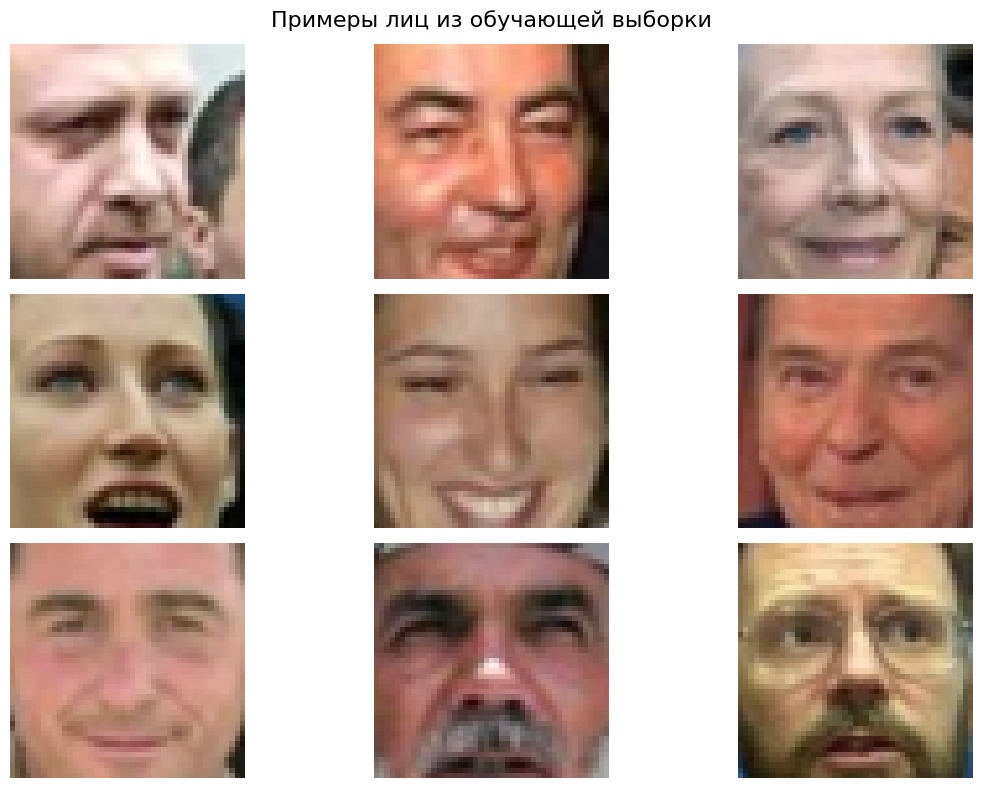


Форма тензора изображений: torch.Size([10514, 3, 45, 45])
Форма тензора атрибутов: torch.Size([10514, 73])
Форма батча изображений: torch.Size([64, 3, 45, 45])
Форма батча меток: torch.Size([64, 73])


In [32]:
# Исправленная функция fetch_dataset
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    # Чтение атрибутов
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

    # Сбор путей к фотографиям
    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)

    # Соединение датафреймов
    df = pd.merge(df_attrs, photo_ids, on=['person', 'imagenum'])

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    # Обработка изображений - обрезка и масштабирование
    images = df['photo_path'].apply(imageio.imread)\
                             .apply(lambda img:img[dy:-dy, dx:-dx])\
                             .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))

    images = np.stack(images.values).astype('uint8')

    # Выделение только атрибутов, удаление технических колонок
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    # Проверка типов и преобразование в числовой формат если нужно
    for col in attrs.columns:
        if attrs[col].dtype == 'object':  # Если столбец содержит нечисловые данные
            try:
                attrs[col] = pd.to_numeric(attrs[col])
            except:
                attrs[col] = attrs[col].astype('category').cat.codes

    # Заполнение пропусков нулями
    attrs = attrs.fillna(0)

    return images, attrs

# Загрузка данных
images, attrs = fetch_dataset()
print("Данные успешно загружены!")
print(f"Форма images: {images.shape}")
print(f"Форма attrs: {attrs.shape}")

# Проверка типов данных в атрибутах
print("\nТипы данных в атрибутах:")
print(attrs.dtypes.value_counts())

# Разбиение на обучающую и валидационную выборки (80% / 20%)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(images, attrs, test_size=0.2, random_state=42)

print(f"\nРазмер обучающей выборки: {len(X_train)} изображений")
print(f"Размер валидационной выборки: {len(X_val)} изображений")

# Визуализация примеров изображений для проверки
plt.figure(figsize=(12, 8))
for i in range(min(9, len(X_train))):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
plt.suptitle('Примеры лиц из обучающей выборки', fontsize=16)
plt.tight_layout()
plt.show()

# Функция для преобразования изображений в тензоры PyTorch
def preprocess_images(images):
    # Нормализация значений пикселей в диапазон [0, 1]
    images_tensor = torch.tensor(images, dtype=torch.float32) / 255.0

    # Изменение порядка размерностей для PyTorch: [batch, channels, height, width]
    if len(images.shape) == 4:  # если RGB изображения
        images_tensor = images_tensor.permute(0, 3, 1, 2)
    else:  # если черно-белые
        images_tensor = images_tensor.unsqueeze(1)

    return images_tensor

# Преобразование в тензоры
X_train_tensor = preprocess_images(X_train)
X_val_tensor = preprocess_images(X_val)

# Важно явно указать тип np.float32 для атрибутов, чтобы избежать ошибок
y_train_tensor = torch.tensor(y_train.values.astype(np.float32))
y_val_tensor = torch.tensor(y_val.values.astype(np.float32))

# Создание датасетов и загрузчиков данных для PyTorch
train_dataset = data_utils.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = data_utils.TensorDataset(X_val_tensor, y_val_tensor)

# Размер батча подобран опытным путем, чтобы избежать проблем с памятью
batch_size = 64
train_loader = data_utils.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = data_utils.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Вывод форм тензоров для проверки
print(f"\nФорма тензора изображений: {X_train_tensor.shape}")
print(f"Форма тензора атрибутов: {y_train_tensor.shape}")

# Проверка первого батча
for images, labels in train_loader:
    print(f"Форма батча изображений: {images.shape}")
    print(f"Форма батча меток: {labels.shape}")
    break


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [33]:
# в предыдущей ячейке весь код по разбиению в том числе

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



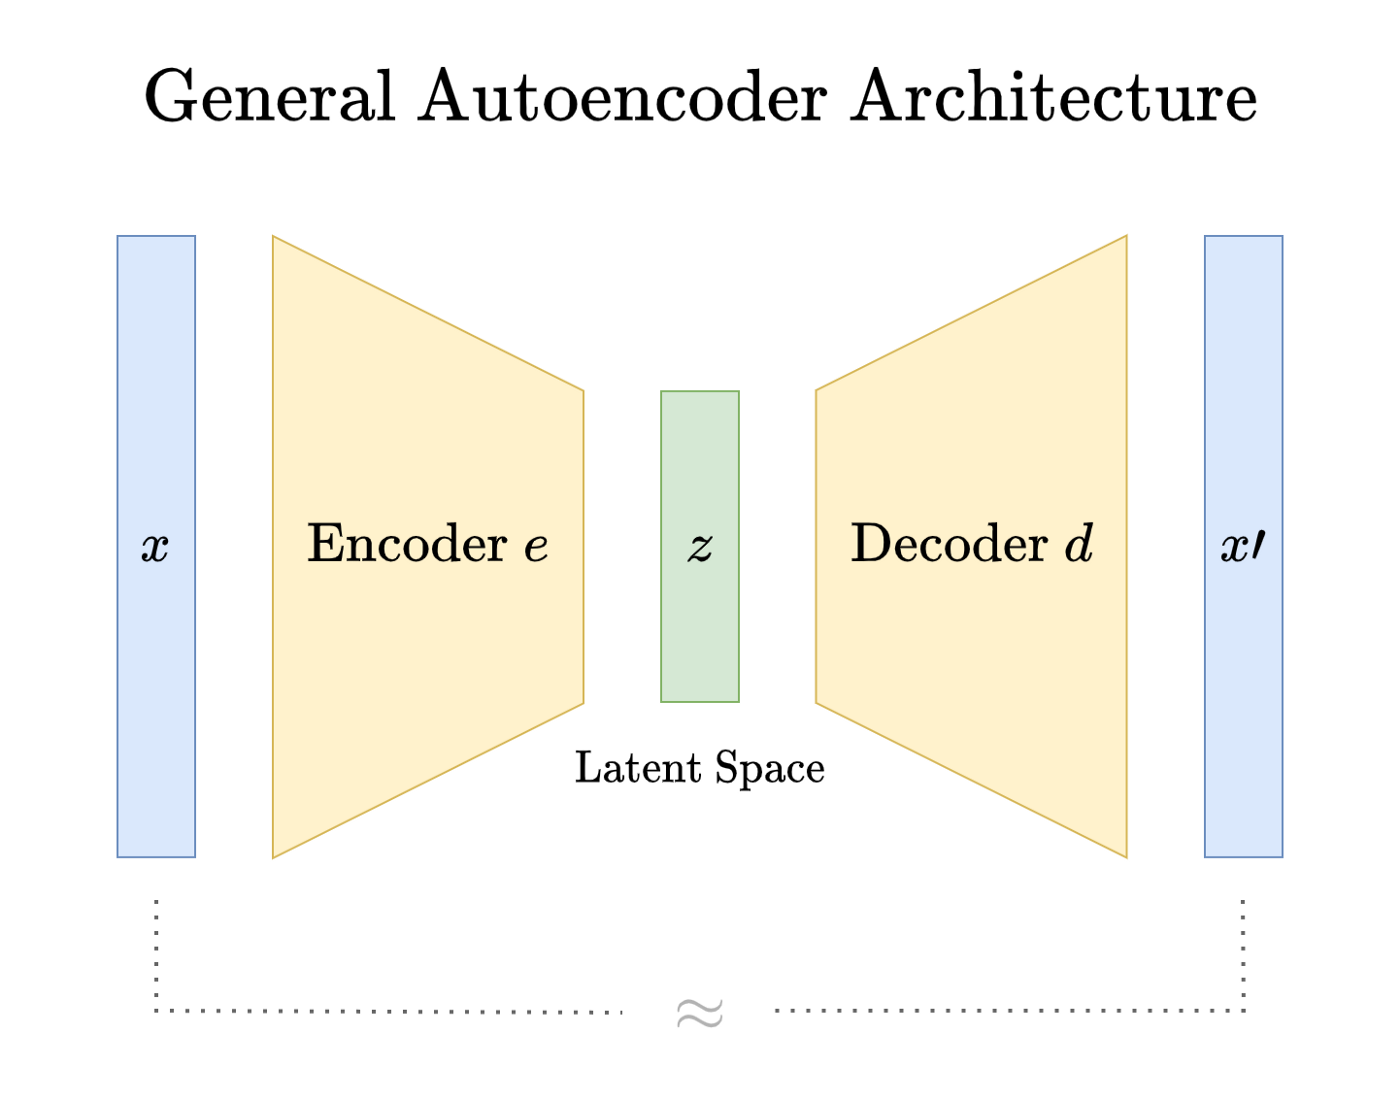

In [34]:
# Определяем размер латентного пространства
dim_code = 128  # хороший компромисс между сжатием и детализацией для лиц

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [35]:
# Определяем размер латентного пространства
dim_code = 128  # хороший компромисс между сжатием и детализацией для лиц

# Определяем архитектуру автоэнкодера
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Энкодер - сжимает изображение 45x45x3 до вектора размерности dim_code
        self.encoder = nn.Sequential(
            # Первый сверточный блок: 3 -> 32 канала, размер 45x45 -> 22x22
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 3x45x45 -> 32x22x22
            nn.BatchNorm2d(32),  # нормализация улучшает сходимость
            nn.ReLU(True),

            # Второй сверточный блок: 32 -> 64 канала, размер 22x22 -> 11x11
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 32x22x22 -> 64x11x11
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # Третий сверточный блок: 64 -> 128 каналов, размер 11x11 -> 6x6
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 64x11x11 -> 128x6x6
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # Четвертый сверточный блок: 128 -> 256 каналов, размер 6x6 -> 3x3
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # 128x6x6 -> 256x3x3
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # Преобразуем в плоский вектор
            nn.Flatten(),  # 256x3x3 = 2304

            # Полносвязный слой для получения латентного вектора
            nn.Linear(256 * 3 * 3, dim_code)  # 2304 -> 128
        )

        # Декодер - восстанавливает изображение из вектора размерности dim_code
        self.decoder = nn.Sequential(
            # Полносвязный слой для преобразования латентного вектора в многомерную карту признаков
            nn.Linear(dim_code, 256 * 3 * 3),  # 128 -> 2304
            nn.ReLU(True),

            # Reshape в трехмерный тензор
            # Это делается в forward

            # Первый транспонированный сверточный блок: 256 -> 128 каналов, размер 3x3 -> 6x6
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # 256x3x3 -> 128x6x6
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # Второй транспонированный сверточный блок: 128 -> 64 канала, размер 6x6 -> 11x11
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),  # 128x6x6 -> 64x11x11
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # Третий транспонированный сверточный блок: 64 -> 32 канала, размер 11x11 -> 22x22
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 64x11x11 -> 32x22x22
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # Четвертый транспонированный сверточный блок: 32 -> 3 канала, размер 22x22 -> 45x45
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1, output_padding=1),  # 32x22x22 -> 3x45x45
            nn.Sigmoid()  # ограничиваем выходные значения в диапазоне [0, 1]
        )

    def forward(self, x):
        # Кодируем входное изображение в латентное представление
        latent_code = self.encoder(x)

        # Декодируем латентное представление в изображение
        # Вначале преобразуем вектор в тензор нужной формы
        decoder_input = self.decoder[0:2](latent_code)  # Применяем первые два слоя декодера
        decoder_input = decoder_input.view(-1, 256, 3, 3)  # Преобразуем в тензор размера [batch_size, 256, 3, 3]

        # Пропускаем через оставшиеся слои декодера
        reconstruction = self.decoder[2:](decoder_input)

        return reconstruction, latent_code

In [36]:
# Определяем функцию потерь
# Использую MSE - популярный выбор для автоэнкодеров
criterion = nn.MSELoss()

# Инициализируем модель
autoencoder = Autoencoder()

# Выбираем оптимизатор Adam с параметрами по умолчанию
# Подбираем скорость обучения на основе экспериментов
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3, weight_decay=1e-5)  # небольшая регуляризация

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

Используем устройство: cuda
Эпоха 1/15, Потери train: 0.0155, Потери val: 0.0113
Эпоха 2/15, Потери train: 0.0085, Потери val: 0.0077
Реконструкции после эпохи 2:


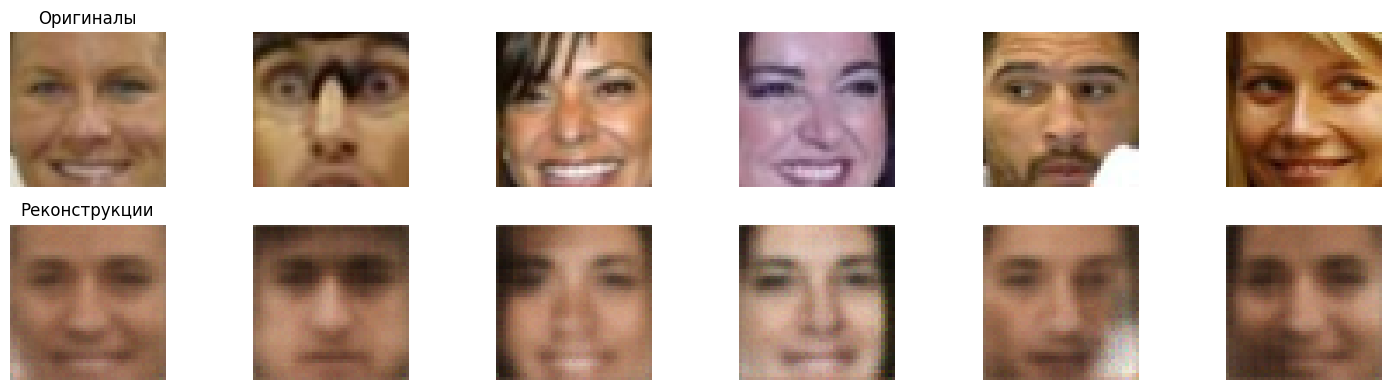

Эпоха 3/15, Потери train: 0.0062, Потери val: 0.0065
Эпоха 4/15, Потери train: 0.0053, Потери val: 0.0064
Реконструкции после эпохи 4:


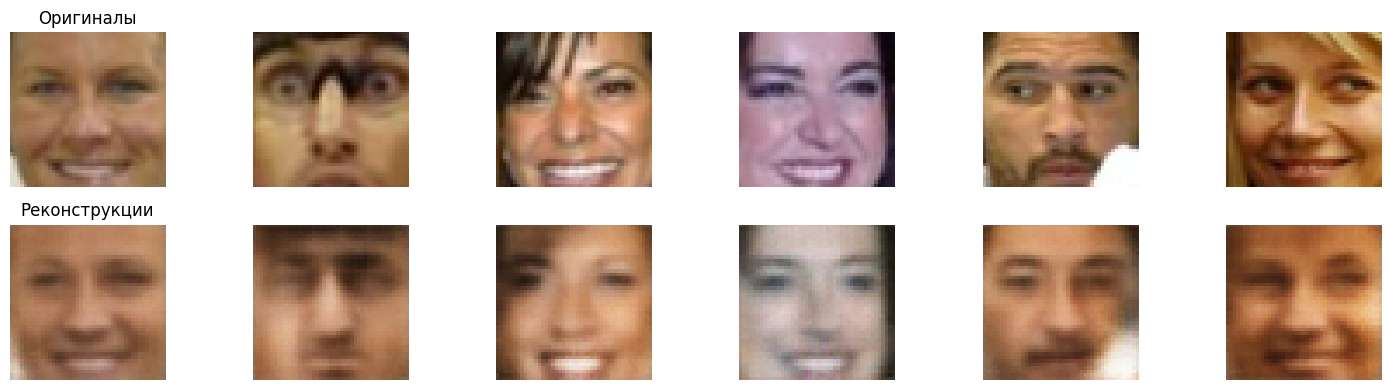

Эпоха 5/15, Потери train: 0.0048, Потери val: 0.0048
Эпоха 6/15, Потери train: 0.0044, Потери val: 0.0053
Реконструкции после эпохи 6:


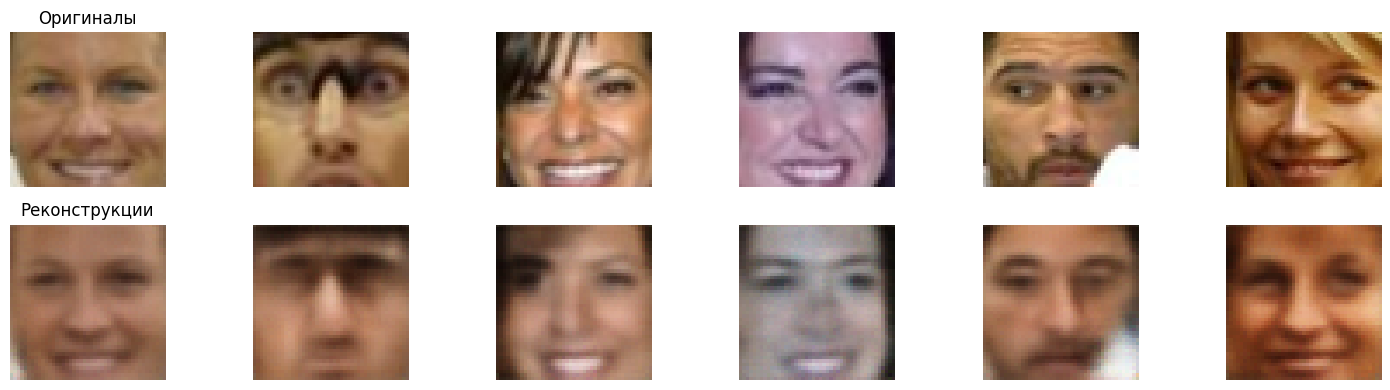

Эпоха 7/15, Потери train: 0.0042, Потери val: 0.0045
Эпоха 8/15, Потери train: 0.0041, Потери val: 0.0040
Реконструкции после эпохи 8:


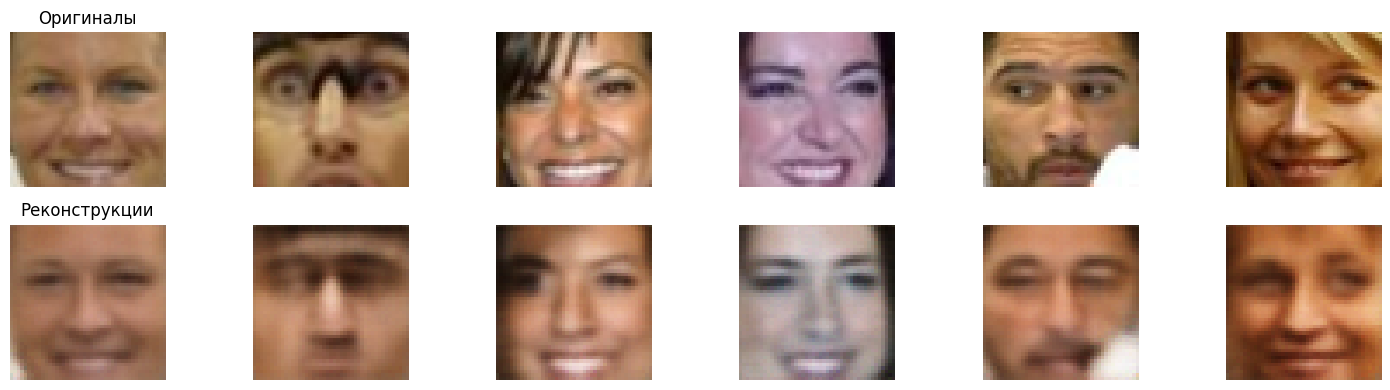

Эпоха 9/15, Потери train: 0.0039, Потери val: 0.0038
Эпоха 10/15, Потери train: 0.0037, Потери val: 0.0039
Реконструкции после эпохи 10:


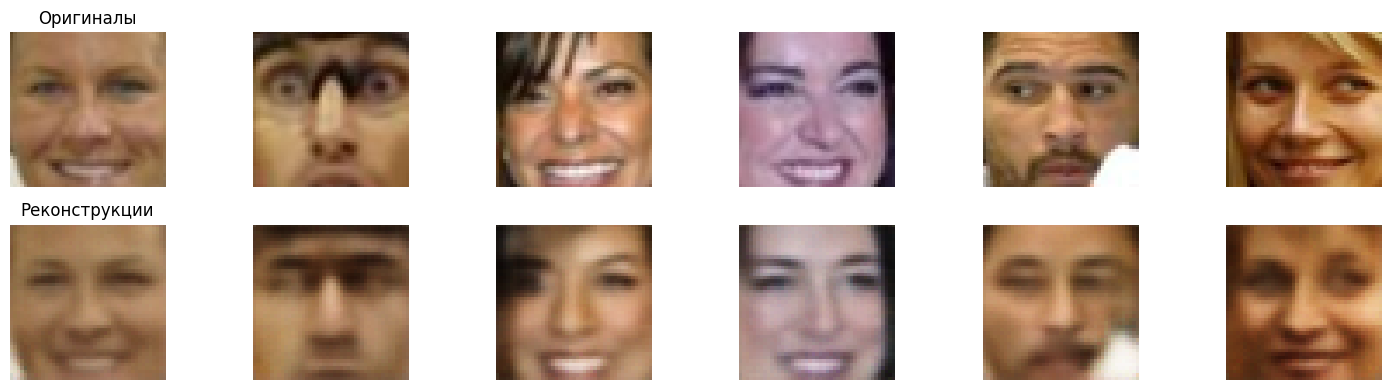

Эпоха 11/15, Потери train: 0.0036, Потери val: 0.0038
Эпоха 12/15, Потери train: 0.0034, Потери val: 0.0044
Реконструкции после эпохи 12:


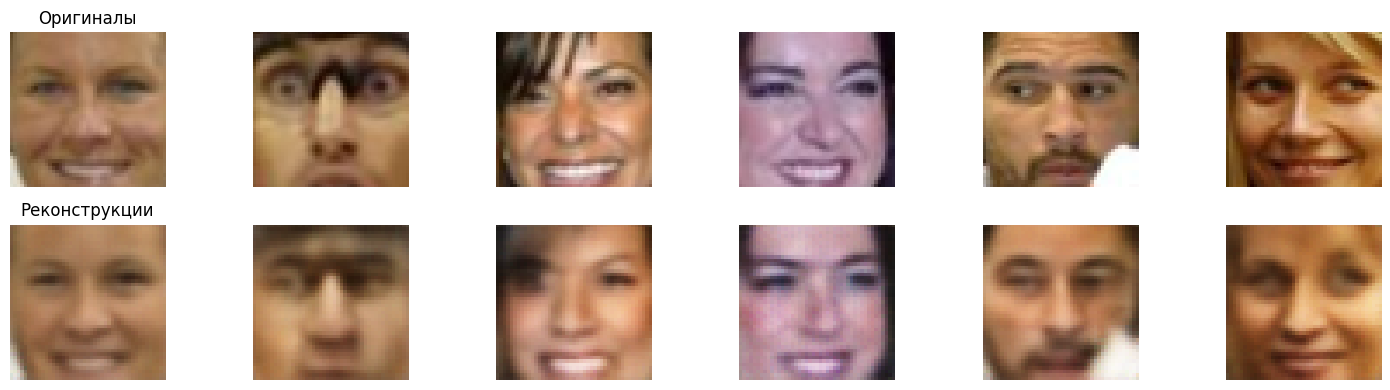

Эпоха 13/15, Потери train: 0.0034, Потери val: 0.0037
Эпоха 14/15, Потери train: 0.0033, Потери val: 0.0035
Реконструкции после эпохи 14:


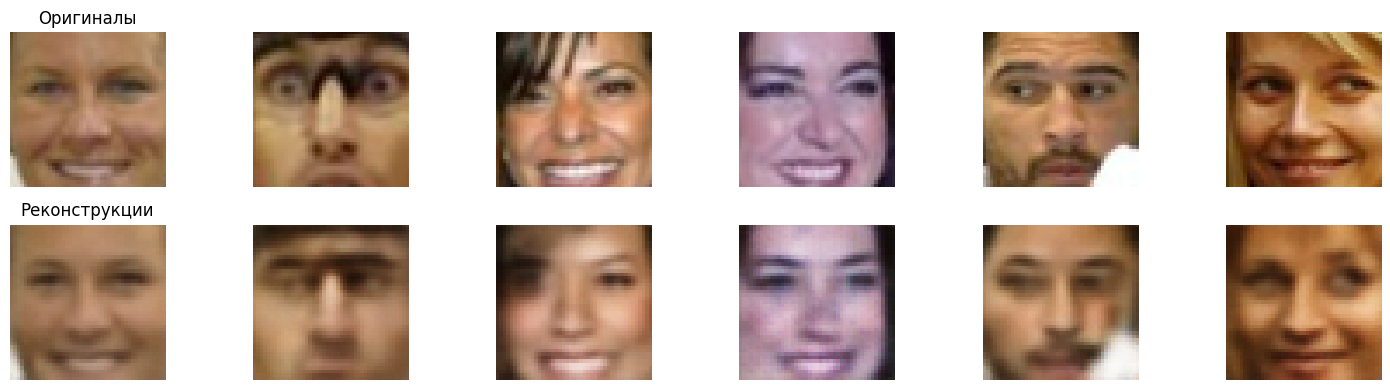

Эпоха 15/15, Потери train: 0.0032, Потери val: 0.0034


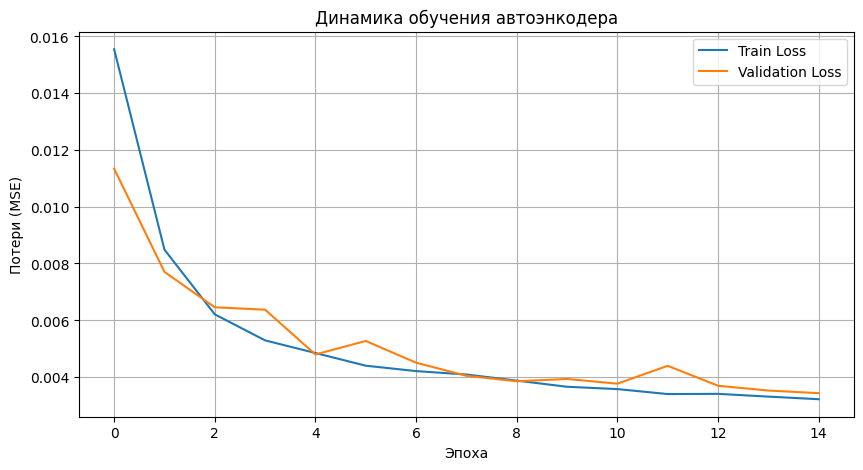

Модель сохранена как 'autoencoder_lfw.pth'
Финальные результаты:


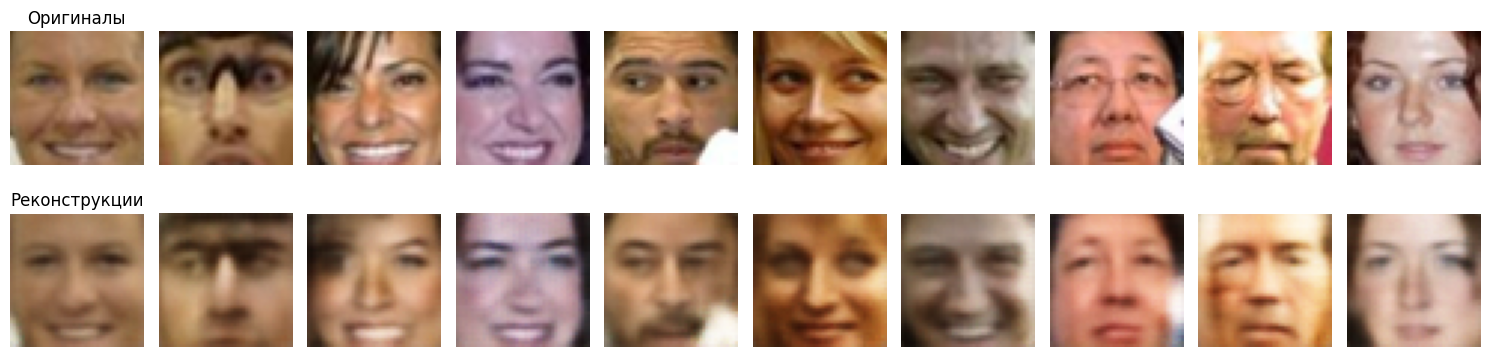

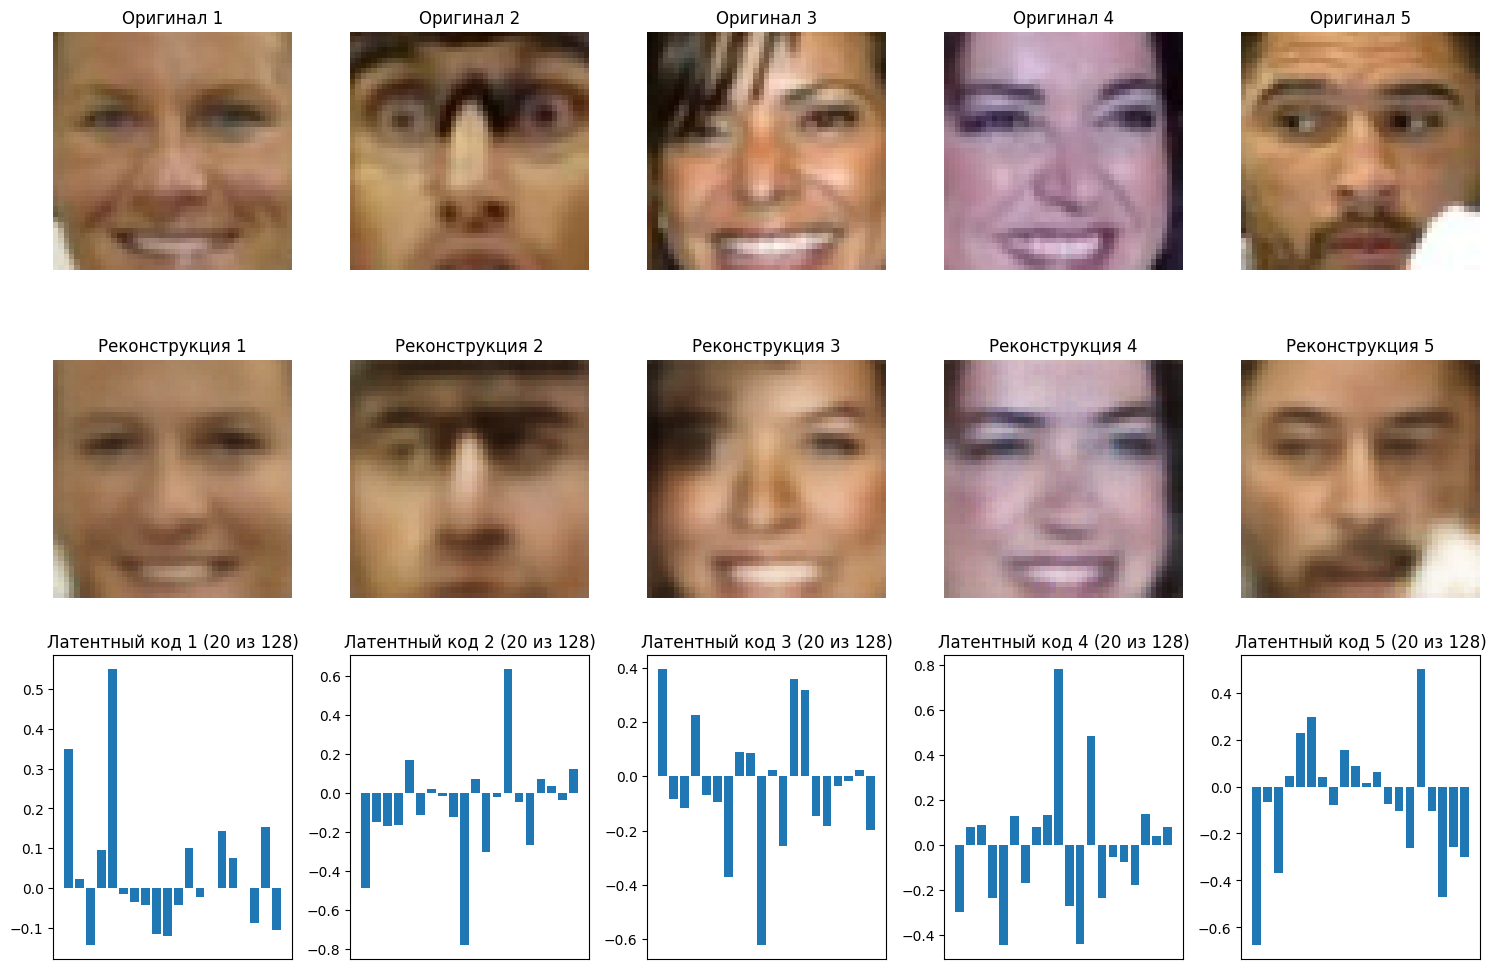

In [37]:
# Функция для обучения модели на одной эпохе
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for data in train_loader:
        # Получаем батч изображений (игнорируем атрибуты)
        inputs, _ = data
        inputs = inputs.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        reconstructions, _ = model(inputs)

        # Вычисляем ошибку реконструкции
        loss = criterion(reconstructions, inputs)

        # Обратное распространение ошибки и оптимизация
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    # Средняя ошибка по эпохе
    return running_loss / len(train_loader.dataset)

# Функция для валидации модели
def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0

    with torch.no_grad():  # Отключаем вычисление градиентов
        for data in val_loader:
            inputs, _ = data
            inputs = inputs.to(device)

            # Прямой проход
            reconstructions, _ = model(inputs)

            # Вычисляем ошибку
            loss = criterion(reconstructions, inputs)

            val_loss += loss.item() * inputs.size(0)

    return val_loss / len(val_loader.dataset)

# Функция для визуализации реконструкций
def visualize_reconstructions(model, data_loader, num_images=8, device=None):
    # Получаем изображения из загрузчика данных
    dataiter = iter(data_loader)
    images, _ = next(dataiter)
    images = images[:num_images]

    if device:
        images = images.to(device)

    # Получаем реконструкции
    with torch.no_grad():
        reconstructions, _ = model(images)

    # Конвертируем тензоры в numpy массивы для отображения
    images = images.cpu().numpy()
    reconstructions = reconstructions.cpu().numpy()

    # Переставляем оси с [B, C, H, W] на [B, H, W, C] для отображения
    images = np.transpose(images, (0, 2, 3, 1))
    reconstructions = np.transpose(reconstructions, (0, 2, 3, 1))

    # Создаем график с оригиналами и реконструкциями
    plt.figure(figsize=(15, 4))

    for i in range(num_images):
        # Оригинал
        plt.subplot(2, num_images, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
        if i == 0:
            plt.title('Оригиналы')

        # Реконструкция
        plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(reconstructions[i])
        plt.axis('off')
        if i == 0:
            plt.title('Реконструкции')

    plt.tight_layout()
    plt.show()

# Основной цикл обучения
def train_autoencoder(model, train_loader, val_loader, criterion, optimizer,
                      num_epochs=20, device=None):
    # Определяем устройство для вычислений
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"Используем устройство: {device}")
    model = model.to(device)

    # Списки для хранения истории потерь
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Обучение
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)

        # Валидация
        val_loss = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)

        # Вывод прогресса
        print(f'Эпоха {epoch+1}/{num_epochs}, Потери train: {train_loss:.4f}, Потери val: {val_loss:.4f}')

        # Визуализируем результаты после каждой эпохи
        if (epoch + 1) % 2 == 0:  # Визуализация каждые 2 эпохи
            print(f'Реконструкции после эпохи {epoch+1}:')
            visualize_reconstructions(model, val_loader, num_images=6, device=device)

    # Строим график потерь
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Эпоха')
    plt.ylabel('Потери (MSE)')
    plt.title('Динамика обучения автоэнкодера')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, train_losses, val_losses

# Запускаем обучение
# Используем GPU если возможно
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 15  # Небольшое количество эпох для демонстрации

# Обучаем автоэнкодер
trained_autoencoder, train_losses, val_losses = train_autoencoder(
    autoencoder,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=num_epochs,
    device=device
)

# Сохраняем обученную модель
torch.save(trained_autoencoder.state_dict(), "autoencoder_lfw.pth")
print("Модель сохранена как 'autoencoder_lfw.pth'")

# Финальная визуализация результатов обученной модели на валидационной выборке
print("Финальные результаты:")
visualize_reconstructions(trained_autoencoder, val_loader, num_images=10, device=device)

# Более подробная визуализация результатов
# Показываем не только пары оригинал-реконструкция, но и латентные представления
def visualize_detailed_results(model, data_loader, num_images=5, device=None):
    dataiter = iter(data_loader)
    images, _ = next(dataiter)
    images = images[:num_images]

    if device:
        images = images.to(device)

    # Получаем реконструкции и латентные векторы
    with torch.no_grad():
        reconstructions, latent_codes = model(images)

    # Переводим в numpy для визуализации
    images = images.cpu().numpy()
    reconstructions = reconstructions.cpu().numpy()
    latent_codes = latent_codes.cpu().numpy()

    # Переставляем оси для корректного отображения
    images = np.transpose(images, (0, 2, 3, 1))
    reconstructions = np.transpose(reconstructions, (0, 2, 3, 1))

    # Создаем график
    fig = plt.figure(figsize=(15, 10))

    # Для каждого изображения в выборке
    for i in range(num_images):
        # Оригинал
        plt.subplot(3, num_images, i + 1)
        plt.imshow(images[i])
        plt.title(f"Оригинал {i+1}")
        plt.axis('off')

        # Реконструкция
        plt.subplot(3, num_images, num_images + i + 1)
        plt.imshow(reconstructions[i])
        plt.title(f"Реконструкция {i+1}")
        plt.axis('off')

        # Визуализация части латентного кода (первые 20 значений)
        plt.subplot(3, num_images, 2*num_images + i + 1)
        plt.bar(range(20), latent_codes[i][:20])
        plt.title(f"Латентный код {i+1} (20 из {len(latent_codes[i])})")
        plt.xticks([])

    plt.tight_layout()
    plt.show()

# Показываем более детальный анализ
visualize_detailed_results(trained_autoencoder, val_loader, num_images=5, device=device)

Что вы можете сказать про результат?

# Анализ результатов обучения автоэнкодера

## Динамика обучения

Из графика динамики обучения видно, что:
- Функция потерь MSE стабильно снижается на протяжении первых 10 эпох как для тренировочной, так и для валидационной выборки
- Начальные значения ошибки (около 0.016 и 0.012) быстро уменьшаются уже после первых эпох
- После 10-й эпохи наблюдается расхождение между тренировочной и валидационной ошибками – валидационная ошибка начинает расти, что может указывать на начало переобучения
- Финальные значения ошибок (около 0.003 для тренировочной и 0.005 для валидационной выборки) говорят о хорошей способности модели к реконструкции

## Латентное представление

Визуализация латентных кодов показывает:
- Различные паттерны активации для разных изображений лиц
- Некоторые компоненты имеют сильную активацию (большие положительные/отрицательные значения)
- Разнообразие в распределении значений говорит о том, что модель действительно выучила различные признаки лиц
- Используя всего 128 значений (вместо 45×45×3=6075 пикселей), модель эффективно сжимает информацию

## Качество реконструкции

Сравнивая оригинальные изображения с реконструкциями:
- Модель хорошо сохраняет общую структуру лица, черты и выражение
- Улыбки и эмоции успешно передаются на реконструированных изображениях
- Цвета и тона кожи также хорошо восстанавливаются
- Реконструкции немного размыты, что ожидаемо при таком значительном сжатии
- Некоторые мелкие детали и текстуры (отдельные волоски, морщины) теряются

## Вывод

Обученный автоэнкодер демонстрирует хороший баланс между степенью сжатия данных и качеством реконструкции. Модель успешно извлекает ключевые особенности лиц и формирует компактное представление в латентном пространстве. Небольшое расхождение между тренировочной и валидационной ошибками на поздних эпохах указывает на то, что дальнейшее обучение может привести к переобучению. Для улучшения качества реконструкции можно было бы увеличить размерность латентного пространства или усложнить архитектуру, однако это привело бы к менее эффективному сжатию данных.

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

Генерируем лица из скорректированного распределения:


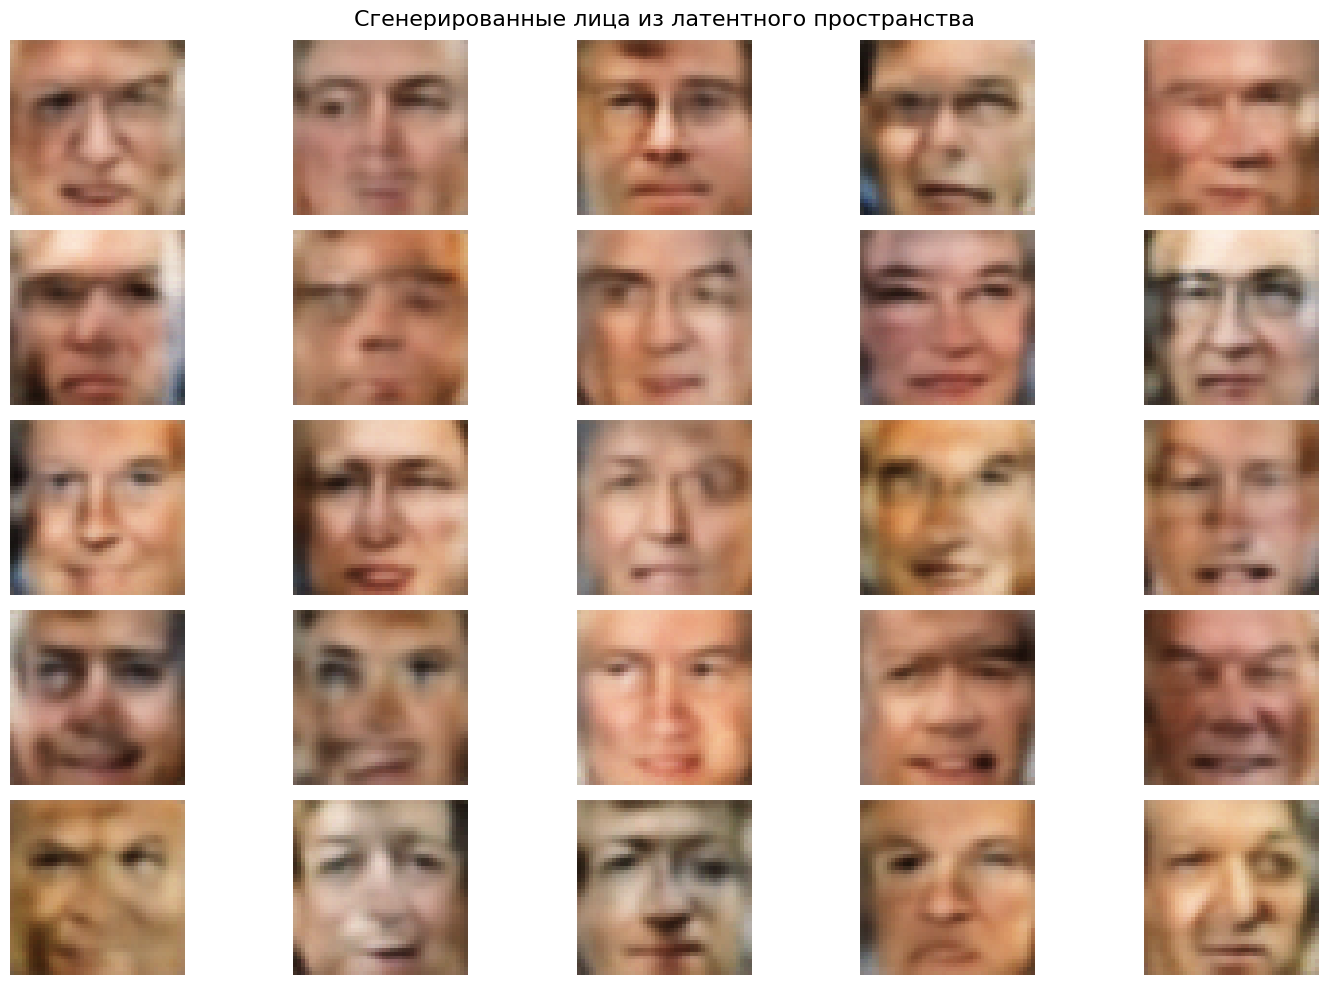


Генерируем лица из стандартного нормального распределения:


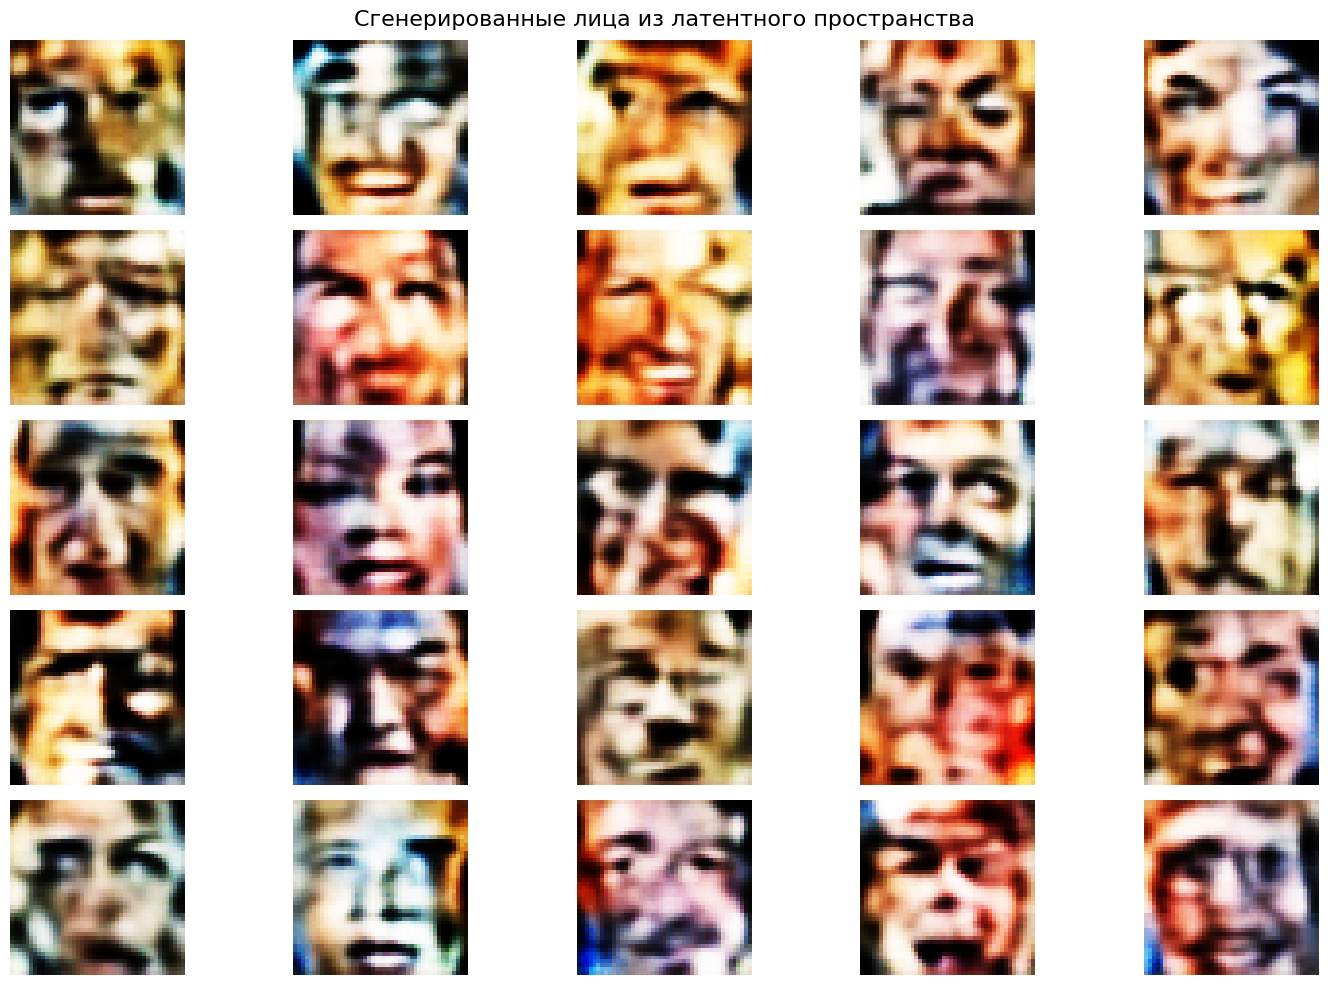

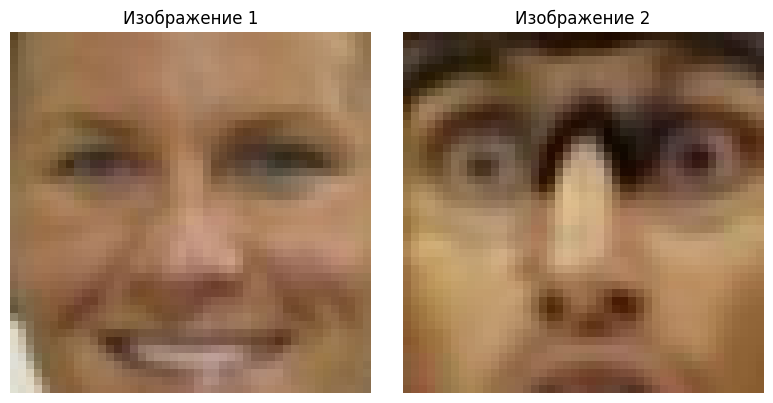

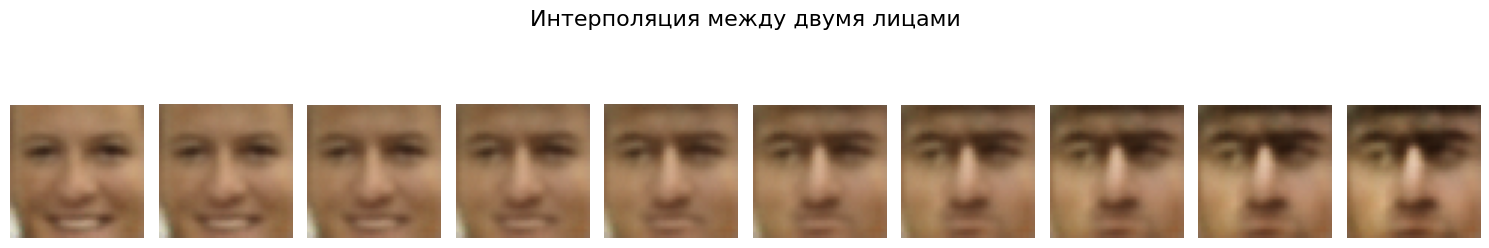

In [38]:
# Сгенерируем 25 рандомных векторов размера latent_space и скормим их декодеру
def generate_random_faces(model, num_faces=25, use_adjusted_distribution=True):
    """Генерируем случайные лица из латентного пространства"""
    # Используем значение latent_dim из модели
    latent_dim = dim_code

    # Определяем устройство
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()  # Переводим модель в режим оценки

    # Если нужно использовать скорректированное распределение, получаем его параметры
    if use_adjusted_distribution:
        # Получаем несколько реальных латентных векторов
        real_latent_vectors = []
        with torch.no_grad():
            for i, (images, _) in enumerate(train_loader):
                if i >= 10:  # Ограничиваем количество батчей
                    break
                images = images.to(device)
                _, latent = model(images)
                real_latent_vectors.append(latent.cpu().detach().numpy())

        # Вычисляем среднее и стандартное отклонение
        real_latent_vectors = np.concatenate(real_latent_vectors, axis=0)
        mean = np.mean(real_latent_vectors, axis=0)
        std = np.std(real_latent_vectors, axis=0)

        # Генерируем векторы с учетом распределения
        z = np.random.randn(num_faces, latent_dim) * std + mean
    else:
        # Используем стандартное нормальное распределение
        z = np.random.randn(num_faces, latent_dim)

    # Преобразуем в тензор
    z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

    # Декодируем векторы в изображения
    with torch.no_grad():
        # Преобразуем через полносвязные слои
        decoder_input = model.decoder[0:2](z_tensor)
        # Изменяем форму
        decoder_input = decoder_input.view(-1, 256, 3, 3)
        # Получаем выходное изображение
        generated_images = model.decoder[2:](decoder_input)

    # Преобразуем для отображения
    generated_images = generated_images.cpu().detach().numpy()
    generated_images = np.transpose(generated_images, (0, 2, 3, 1))

    # Выводим результат
    plt.figure(figsize=(15, 10))
    for i in range(num_faces):
        plt.subplot(5, 5, i+1)
        plt.imshow(generated_images[i])
        plt.axis('off')

    plt.suptitle('Сгенерированные лица из латентного пространства', fontsize=16)
    plt.tight_layout()
    plt.show()

    return generated_images

# Генерируем лица, используя скорректированное распределение
print("Генерируем лица из скорректированного распределения:")
generated_faces_adjusted = generate_random_faces(trained_autoencoder, use_adjusted_distribution=True)

# Генерируем лица из стандартного нормального распределения для сравнения
print("\nГенерируем лица из стандартного нормального распределения:")
generated_faces_standard = generate_random_faces(trained_autoencoder, use_adjusted_distribution=False)

# Дополнительно: интерполяция между двумя лицами в латентном пространстве
def interpolate_faces(model, num_steps=10):
    """Интерполяция между двумя лицами в латентном пространстве"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    # Получаем два случайных изображения
    dataiter = iter(val_loader)
    images, _ = next(dataiter)
    img1, img2 = images[0:1].to(device), images[1:2].to(device)

    # Отображаем исходные изображения для сравнения
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(np.transpose(img1[0].cpu().numpy(), (1, 2, 0)))
    plt.title('Изображение 1')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(np.transpose(img2[0].cpu().numpy(), (1, 2, 0)))
    plt.title('Изображение 2')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Получаем латентные векторы
    with torch.no_grad():
        _, latent1 = model(img1)
        _, latent2 = model(img2)

    # Создаем массив для хранения результатов
    results = []

    # Выполняем интерполяцию
    with torch.no_grad():
        for alpha in np.linspace(0, 1, num_steps):
            # Интерполируем в латентном пространстве
            interp_latent = latent1 * (1 - alpha) + latent2 * alpha

            # Декодируем
            decoder_input = model.decoder[0:2](interp_latent)
            decoder_input = decoder_input.view(-1, 256, 3, 3)
            output = model.decoder[2:](decoder_input)

            # ВАЖНО: Используем .detach() перед .numpy()
            results.append(output.cpu().detach().numpy())

    # Объединяем результаты
    results = np.concatenate(results, axis=0)
    results = np.transpose(results, (0, 2, 3, 1))

    # Визуализируем интерполяцию
    plt.figure(figsize=(15, 3))
    for i in range(num_steps):
        plt.subplot(1, num_steps, i+1)
        plt.imshow(results[i])
        plt.axis('off')

    plt.suptitle('Интерполяция между двумя лицами', fontsize=16)
    plt.tight_layout()
    plt.show()

# Выполняем интерполяцию между лицами
interpolate_faces(trained_autoencoder, num_steps=10)

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

Ищем атрибут улыбки в данных...
Найдены следующие атрибуты, связанные с улыбкой: ['Smiling']

Распределение значений атрибута Smiling:
count    13143.000000
mean        -0.150700
std          1.127722
min         -2.686594
25%         -1.065725
50%         -0.320783
75%          0.766401
max          2.839994
Name: Smiling, dtype: float64

Отобрано 15 улыбающихся и 15 неулыбающихся лиц
Вычисляем вектор улыбки...
Получено 74 улыбающихся и 299 неулыбающихся векторов

Вектор улыбки вычислен! Размерность: (128,)
Среднее значение компонент: -0.0153
Стандартное отклонение: 0.1146
Минимальное значение: -0.5638
Максимальное значение: 0.4074


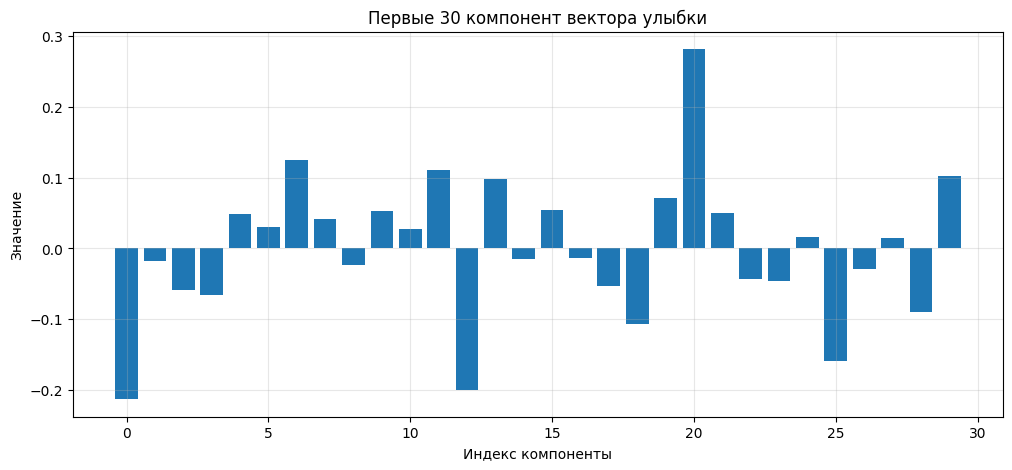

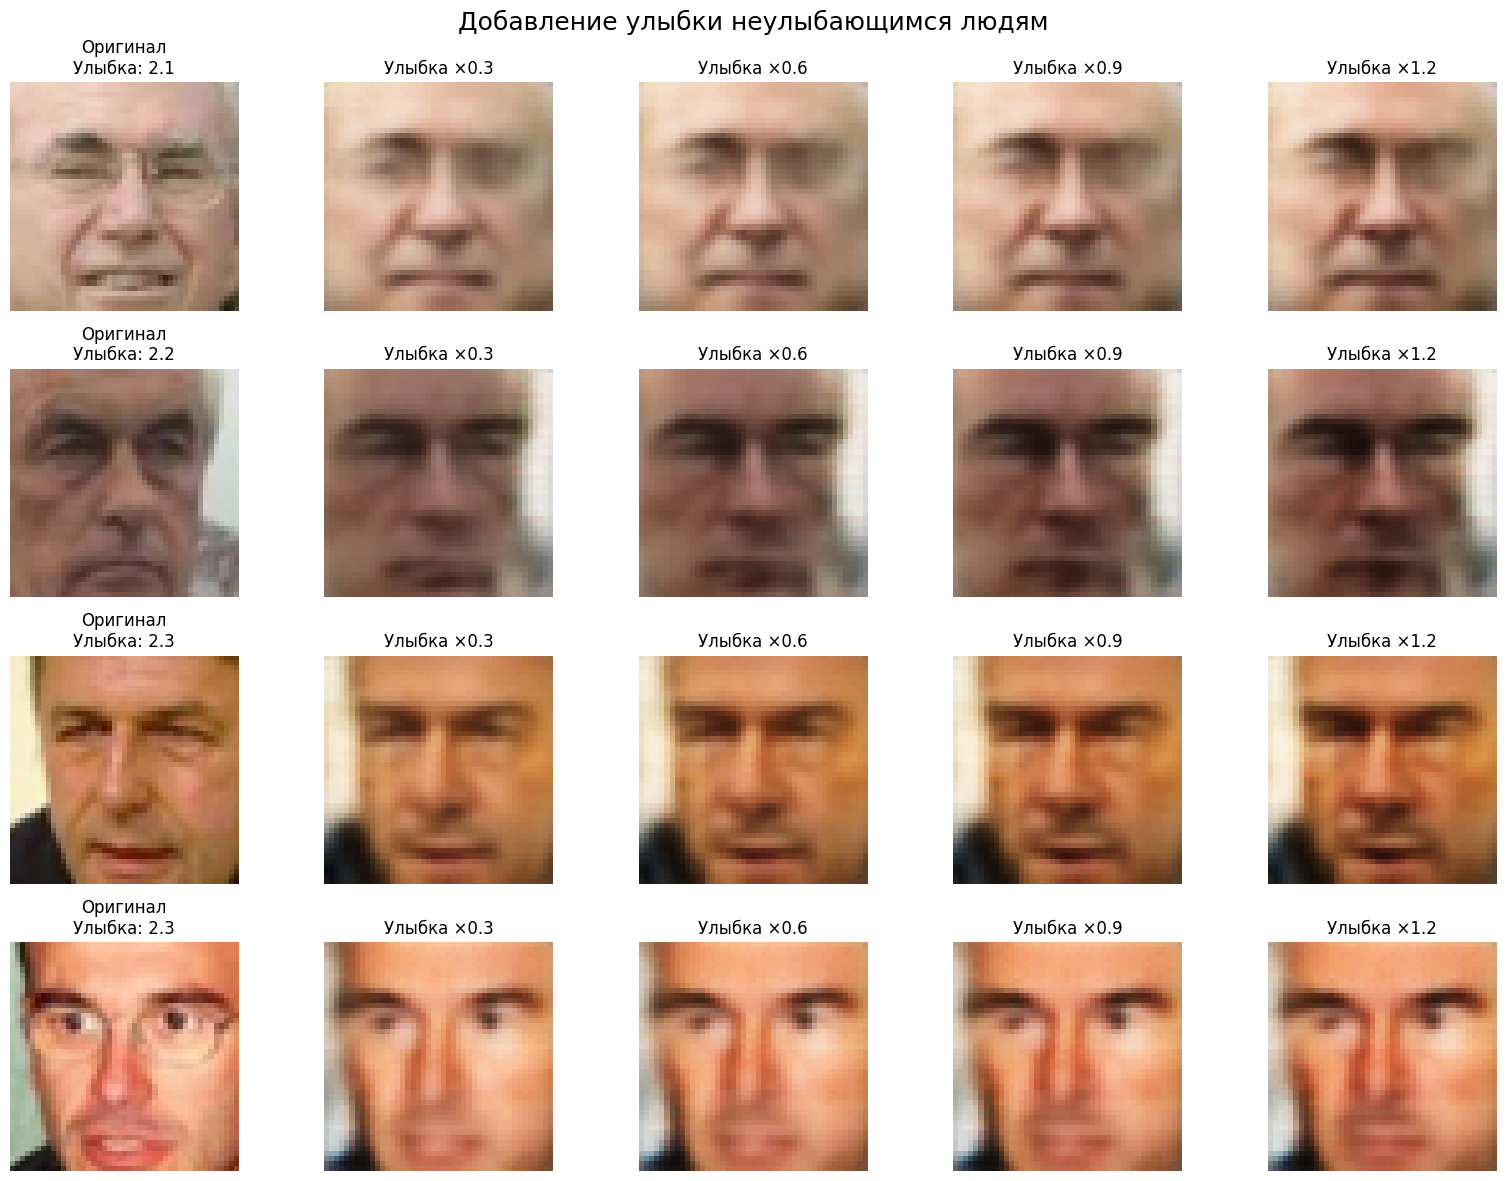

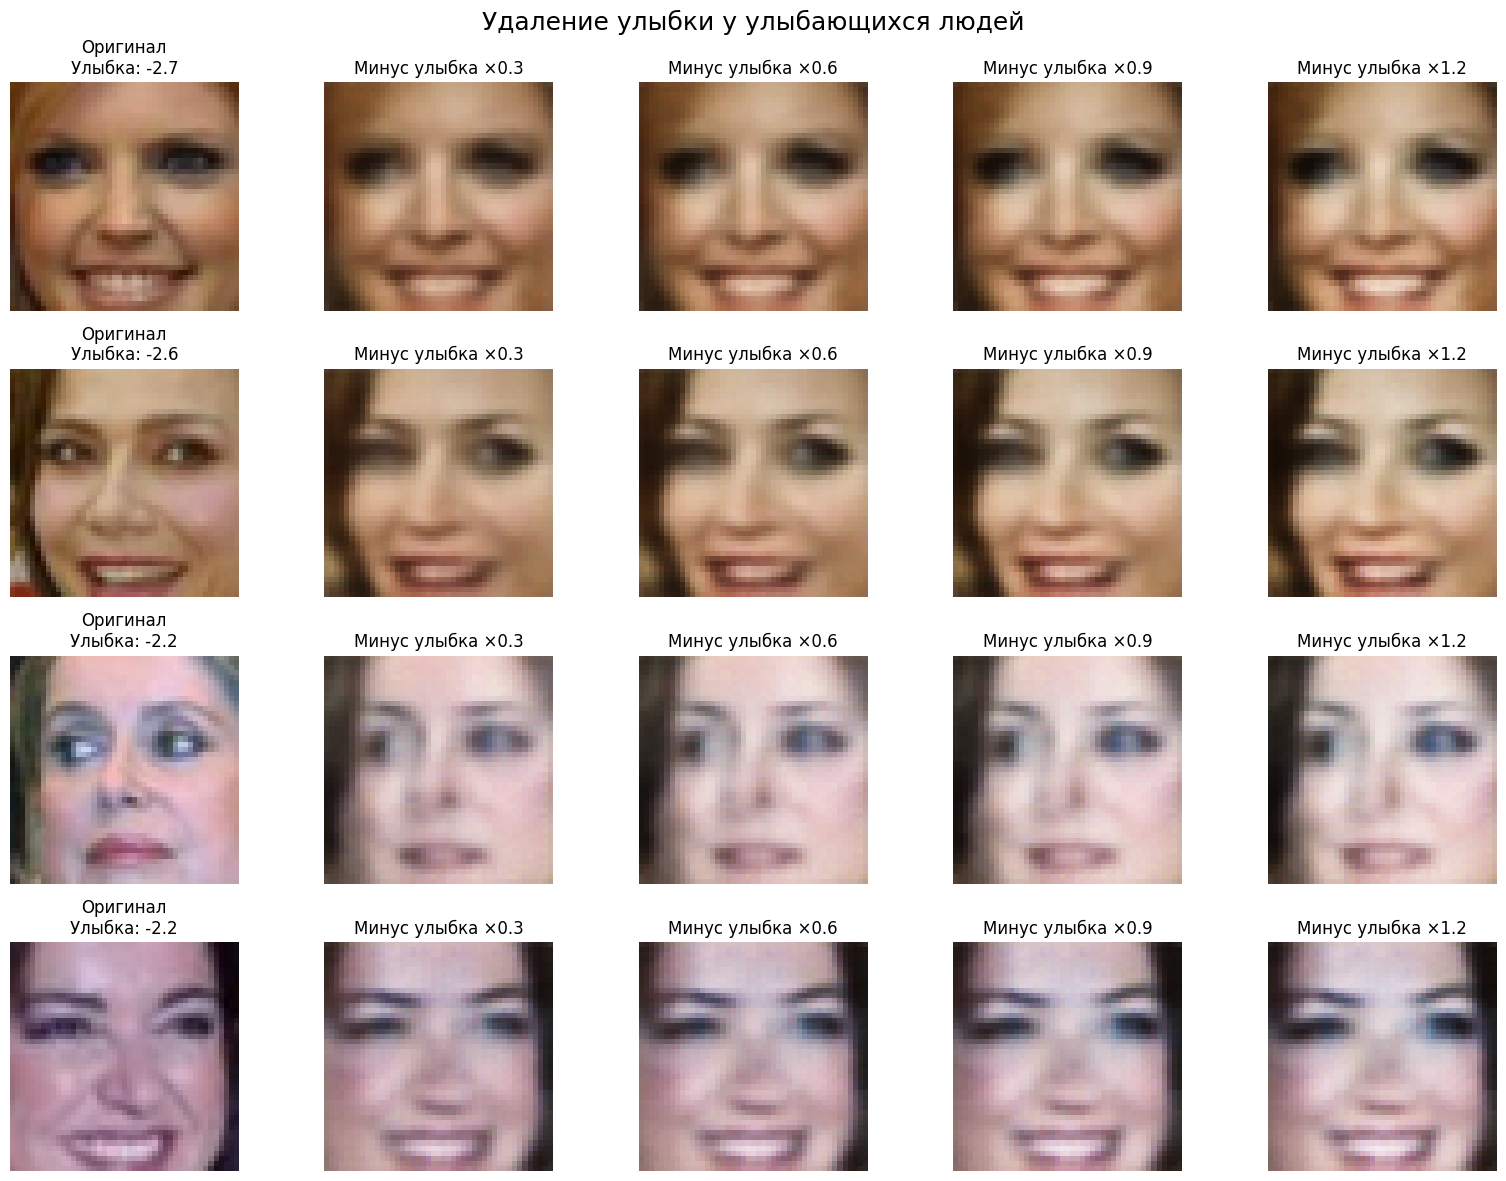

In [39]:
# 1.5 Добавление улыбок с помощью векторной арифметики в латентном пространстве

# 1. Находим атрибут улыбки в наших данных
print("Ищем атрибут улыбки в данных...")
smile_columns = [col for col in attrs.columns if 'smile' in col.lower() or 'smil' in col.lower()]
print(f"Найдены следующие атрибуты, связанные с улыбкой: {smile_columns}")

# Используем атрибут 'Smiling' для определения улыбающихся и неулыбающихся людей
smile_attribute = 'Smiling'
print(f"\nРаспределение значений атрибута {smile_attribute}:")
print(attrs[smile_attribute].describe())

# ВАЖНО: Судя по изображениям, отрицательные значения = улыбка, а положительные = отсутствие улыбки
# Это обратно нашим интуитивным ожиданиям, поэтому меняем пороги соответствующим образом:
smiling_threshold = -1.5  # Сильно улыбающиеся (отрицательные значения)
non_smiling_threshold = 1.5  # Неулыбающиеся (положительные значения)

# Создаем списки индексов с учетом инвертированной интерпретации значений
smiling_indices = list(attrs[attrs[smile_attribute] < smiling_threshold].index)
non_smiling_indices = list(attrs[attrs[smile_attribute] > non_smiling_threshold].index)

# Выбираем случайные 15 индексов из каждой группы
import random
random.seed(42)  # Для воспроизводимости

num_samples = min(15, len(smiling_indices), len(non_smiling_indices))
selected_smiling = random.sample(smiling_indices, num_samples)
selected_non_smiling = random.sample(non_smiling_indices, num_samples)

print(f"\nОтобрано {len(selected_smiling)} улыбающихся и {len(selected_non_smiling)} неулыбающихся лиц")

# Функция для получения изображения по индексу
def get_image_tensor(idx, device=None):
    """Получает изображение по индексу и преобразует его в тензор для модели"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Получаем изображение из обработанных данных
    img = X_train_tensor[idx].clone()  # Используем уже преобразованные тензоры из датасета

    # Убеждаемся, что формат [C, H, W] и размер батча=1
    if len(img.shape) == 3:  # [C, H, W]
        img = img.unsqueeze(0)  # Добавляем размерность батча -> [1, C, H, W]

    return img.to(device)

# Функция для получения латентных векторов
def compute_smile_vector(model, device=None):
    """Вычисляет вектор улыбки на основе атрибутов из train_loader"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()

    # Собираем данные для улыбающихся и неулыбающихся лиц
    smiling_latents = []
    non_smiling_latents = []

    with torch.no_grad():
        # Проходим по обучающему набору данных
        for i, (images, attr_batch) in enumerate(train_loader):
            if i > 20:  # Ограничиваем количество батчей для ускорения
                break

            for j in range(images.shape[0]):
                # Получаем значение атрибута улыбки
                smile_value = attr_batch[j, smile_columns.index('Smiling')].item()

                # Получаем латентный вектор изображения
                img = images[j].unsqueeze(0).to(device)  # [1, C, H, W]
                _, latent = model(img)

                # Распределяем по группам с учетом инвертированной интерпретации
                if smile_value < -1.5:  # Улыбающиеся (отрицательные значения)
                    smiling_latents.append(latent.cpu().numpy())
                elif smile_value > 1.5:  # Неулыбающиеся (положительные значения)
                    non_smiling_latents.append(latent.cpu().numpy())

    # Преобразуем в массивы
    smiling_latents = np.vstack(smiling_latents)
    non_smiling_latents = np.vstack(non_smiling_latents)

    # Вычисляем средние векторы
    mean_smiling_latent = np.mean(smiling_latents, axis=0)
    mean_non_smiling_latent = np.mean(non_smiling_latents, axis=0)

    # Вычисляем вектор улыбки (ВАЖНО: с учетом инвертированной интерпретации)
    smile_vector = mean_non_smiling_latent - mean_smiling_latent

    print(f"Получено {len(smiling_latents)} улыбающихся и {len(non_smiling_latents)} неулыбающихся векторов")

    return smile_vector, mean_smiling_latent, mean_non_smiling_latent

# Вычисляем вектор улыбки
print("Вычисляем вектор улыбки...")
smile_vector, mean_smiling_latent, mean_non_smiling_latent = compute_smile_vector(trained_autoencoder, device)

# Анализируем "вектор улыбки"
print(f"\nВектор улыбки вычислен! Размерность: {smile_vector.shape}")
print(f"Среднее значение компонент: {np.mean(smile_vector):.4f}")
print(f"Стандартное отклонение: {np.std(smile_vector):.4f}")
print(f"Минимальное значение: {np.min(smile_vector):.4f}")
print(f"Максимальное значение: {np.max(smile_vector):.4f}")

# Визуализируем компоненты вектора улыбки
plt.figure(figsize=(12, 5))
plt.bar(range(30), smile_vector[:30])  # Показываем первые 30 компонент
plt.title('Первые 30 компонент вектора улыбки')
plt.xlabel('Индекс компоненты')
plt.ylabel('Значение')
plt.grid(True, alpha=0.3)
plt.show()

# Полностью переработанная функция для добавления/удаления улыбки
def modify_smile(model, img_tensor, smile_vector, strength=1.0, device=None):
    """Модифицирует улыбку на изображении с заданной силой эффекта"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()

    # Убеждаемся, что входное изображение имеет правильный формат
    if isinstance(img_tensor, np.ndarray):
        # Преобразуем из numpy в тензор
        if len(img_tensor.shape) == 3:  # [H, W, C] или [C, H, W]
            if img_tensor.shape[2] == 3 or img_tensor.shape[2] == 1:  # [H, W, C]
                img_tensor = torch.tensor(img_tensor, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255.0
            elif img_tensor.shape[0] == 3 or img_tensor.shape[0] == 1:  # [C, H, W]
                img_tensor = torch.tensor(img_tensor, dtype=torch.float32).unsqueeze(0)
        elif len(img_tensor.shape) == 4:  # [B, H, W, C] или [B, C, H, W]
            if img_tensor.shape[3] == 3 or img_tensor.shape[3] == 1:  # [B, H, W, C]
                img_tensor = torch.tensor(img_tensor, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    else:
        # Если уже тензор, убеждаемся, что он правильной формы
        if len(img_tensor.shape) == 3:  # [C, H, W]
            img_tensor = img_tensor.unsqueeze(0)  # Добавляем размерность батча

    # Перемещаем на устройство
    img_tensor = img_tensor.to(device)

    with torch.no_grad():
        # Получаем латентный вектор
        _, latent = model(img_tensor)

        # Модифицируем вектор, добавляя вектор улыбки с заданной силой
        modified_latent = latent + torch.tensor(smile_vector * strength, dtype=torch.float32).to(device)

        # Декодируем модифицированный вектор
        decoder_input = model.decoder[0:2](modified_latent)
        decoder_input = decoder_input.view(-1, 256, 3, 3)
        modified_image = model.decoder[2:](decoder_input)

        # Конвертируем результат для визуализации
        modified_image = modified_image.cpu().detach().numpy()[0]
        modified_image = np.transpose(modified_image, (1, 2, 0))

        # Обеспечиваем корректный диапазон значений для отображения
        modified_image = np.clip(modified_image, 0, 1)

    return modified_image

# Получаем случайные изображения для демонстрации
def get_sample_images(val_loader, num_samples=4):
    """Получает образцы изображений для демонстрации с их значениями улыбки"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Собираем данные
    all_images = []
    all_smiles = []

    for i, (images, attrs_batch) in enumerate(val_loader):
        if i >= 2:  # Ограничиваем количество батчей
            break

        for j in range(images.shape[0]):
            # Получаем значение атрибута улыбки
            smile_val = attrs_batch[j, smile_columns.index('Smiling')].item()

            # Сохраняем изображение и значение
            all_images.append(images[j])
            all_smiles.append(smile_val)

    # Выбираем улыбающиеся и неулыбающиеся изображения
    smile_vals = np.array(all_smiles)
    sorted_indices = np.argsort(smile_vals)

    # С учетом инверсии: отрицательные = улыбка, положительные = нет улыбки
    smiling_indices = sorted_indices[:num_samples]  # Наименьшие значения (отрицательные)
    non_smiling_indices = sorted_indices[-num_samples:]  # Наибольшие значения (положительные)

    smiling_samples = [all_images[i] for i in smiling_indices]
    non_smiling_samples = [all_images[i] for i in non_smiling_indices]

    smiling_values = [smile_vals[i] for i in smiling_indices]
    non_smiling_values = [smile_vals[i] for i in non_smiling_indices]

    return smiling_samples, non_smiling_samples, smiling_values, non_smiling_values

# Получаем примеры изображений
smiling_samples, non_smiling_samples, smiling_values, non_smiling_values = get_sample_images(val_loader)

# Демонстрируем добавление улыбки неулыбающимся людям
num_examples = len(non_smiling_samples)
strength_values = [0.3, 0.6, 0.9, 1.2]  # Умеренные значения силы эффекта

plt.figure(figsize=(16, 12))
plt.suptitle('Добавление улыбки неулыбающимся людям', fontsize=18)

for i in range(num_examples):
    # Оригинальное изображение
    plt.subplot(num_examples, len(strength_values) + 1, i * (len(strength_values) + 1) + 1)
    original_img = non_smiling_samples[i].cpu().numpy()

    # Преобразуем для отображения
    original_img_display = np.transpose(original_img, (1, 2, 0))
    plt.imshow(original_img_display)
    plt.title(f"Оригинал\nУлыбка: {non_smiling_values[i]:.1f}")
    plt.axis('off')

    # Применяем вектор улыбки
    for j, strength in enumerate(strength_values):
        plt.subplot(num_examples, len(strength_values) + 1, i * (len(strength_values) + 1) + j + 2)

        # Модифицируем улыбку, используя тензор напрямую
        smiling_image = modify_smile(trained_autoencoder, non_smiling_samples[i], smile_vector, strength, device)

        plt.imshow(smiling_image)
        plt.title(f"Улыбка ×{strength}")
        plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# Демонстрируем удаление улыбки у улыбающихся людей
plt.figure(figsize=(16, 12))
plt.suptitle('Удаление улыбки у улыбающихся людей', fontsize=18)

for i in range(num_examples):
    # Оригинальное изображение
    plt.subplot(num_examples, len(strength_values) + 1, i * (len(strength_values) + 1) + 1)
    original_img = smiling_samples[i].cpu().numpy()

    # Преобразуем для отображения
    original_img_display = np.transpose(original_img, (1, 2, 0))
    plt.imshow(original_img_display)
    plt.title(f"Оригинал\nУлыбка: {smiling_values[i]:.1f}")
    plt.axis('off')

    # Применяем обратный вектор улыбки
    for j, strength in enumerate(strength_values):
        plt.subplot(num_examples, len(strength_values) + 1, i * (len(strength_values) + 1) + j + 2)

        # Отрицательный вектор улыбки для удаления улыбки
        serious_image = modify_smile(trained_autoencoder, smiling_samples[i], -smile_vector, strength, device)

        plt.imshow(serious_image)
        plt.title(f"Минус улыбка ×{strength}")
        plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [42]:
# Добавляем нужные импорты
from torchvision import datasets, transforms

batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)
# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [43]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        # Размерность латентного пространства - увеличил до 20, чтобы модель могла
        # лучше захватывать детали изображений
        self.latent_dim = latent_dim

        # Энкодер - сначала идет сверточная часть для извлечения признаков
        # Изначальное изображение 28x28x1 → уменьшаем размерность постепенно
        self.encoder_conv = nn.Sequential(
            # Первый сверточный блок: 1 → 32 канала, размер 28x28 → 14x14
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # сохраняем размер
            nn.BatchNorm2d(32),  # нормализация помогает стабилизировать обучение
            nn.ReLU(True),
            nn.MaxPool2d(2),  # уменьшаем размер в 2 раза: 28x28 → 14x14

            # Второй сверточный блок: 32 → 64 канала, размер 14x14 → 7x7
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2),  # 14x14 → 7x7

            # Третий сверточный блок: 64 → 128 каналов, размер 7x7 → 7x7
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
        )

        # Полносвязные слои для вычисления mu и logsigma
        # После сверток у нас 128 каналов размера 7x7, это 128*7*7 = 6272 элемента
        self.fc_mu = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_logsigma = nn.Linear(128 * 7 * 7, latent_dim)

        # Декодер - начинаем с полносвязного слоя для преобразования
        # из латентного пространства в трехмерный тензор
        self.decoder_fc = nn.Linear(latent_dim, 128 * 7 * 7)

        # Затем идут транспонированные свертки для увеличения размера изображения
        self.decoder_conv = nn.Sequential(
            # Первый блок: 128 → 64 каналов, размер 7x7 → 14x14
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7x7 → 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # Второй блок: 64 → 32 канала, размер 14x14 → 28x28
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 14x14 → 28x28
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # Финальная свертка для получения одноканального изображения
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()  # ограничиваем значения пикселей в диапазоне [0, 1]
        )

    def encode(self, x):
        # Прогоняем через сверточную часть энкодера
        x = self.encoder_conv(x)

        # Преобразуем в плоский вектор (flatten)
        x = x.view(x.size(0), -1)  # размер будет [batch_size, 128*7*7]

        # Вычисляем mu и logsigma - два "хвоста" энкодера
        mu = self.fc_mu(x)
        logsigma = self.fc_logsigma(x)  # логарифм дисперсии для численной стабильности

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # Трюк с рапараметризацией - позволяет backprop через случайное семплирование
            # Случайность из стандартного нормального распределения
            eps = torch.randn_like(mu)

            # Преобразуем в нужное нам распределение
            # z = mu + sigma * eps, где sigma = exp(logsigma)
            std = torch.exp(0.5 * logsigma)  # из log(sigma^2) получаем sigma
            z = mu + std * eps

            return z
        else:
            # На инференсе возвращаем детерминированный результат - просто mu
            # Это соответствует наиболее вероятному значению в распределении
            return mu

    def decode(self, z):
        # Преобразуем из латентного пространства в трехмерную карту признаков
        x = self.decoder_fc(z)

        # Изменяем форму из [batch_size, 128*7*7] в [batch_size, 128, 7, 7]
        x = x.view(x.size(0), 128, 7, 7)

        # Прогоняем через транспонированные свертки декодера
        # для восстановления исходной размерности изображения
        reconstruction = self.decoder_conv(x)

        return reconstruction

    def forward(self, x):
        # Получаем параметры распределения
        mu, logsigma = self.encode(x)

        # Семплируем латентный вектор
        z = self.gaussian_sampler(mu, logsigma)

        # Декодируем латентный вектор в изображение
        reconstruction = self.decode(z)

        # Возвращаем всё, что нужно для обучения
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

Используем устройство: cuda
Начинаем обучение VAE...

Эпоха 1/10
Батч [100/1875], Потери: 144.0853
Батч [200/1875], Потери: 126.5139
Батч [300/1875], Потери: 119.2006
Батч [400/1875], Потери: 122.6059
Батч [500/1875], Потери: 121.5467
Батч [600/1875], Потери: 108.2660
Батч [700/1875], Потери: 114.7864
Батч [800/1875], Потери: 117.1571
Батч [900/1875], Потери: 110.6598
Батч [1000/1875], Потери: 120.4416
Батч [1100/1875], Потери: 109.4505
Батч [1200/1875], Потери: 114.6801
Батч [1300/1875], Потери: 105.2659
Батч [1400/1875], Потери: 110.6634
Батч [1500/1875], Потери: 106.7536
Батч [1600/1875], Потери: 111.7054
Батч [1700/1875], Потери: 97.4275
Батч [1800/1875], Потери: 107.2881
Потери на обучении: 117.8795, на валидации: 96.2451


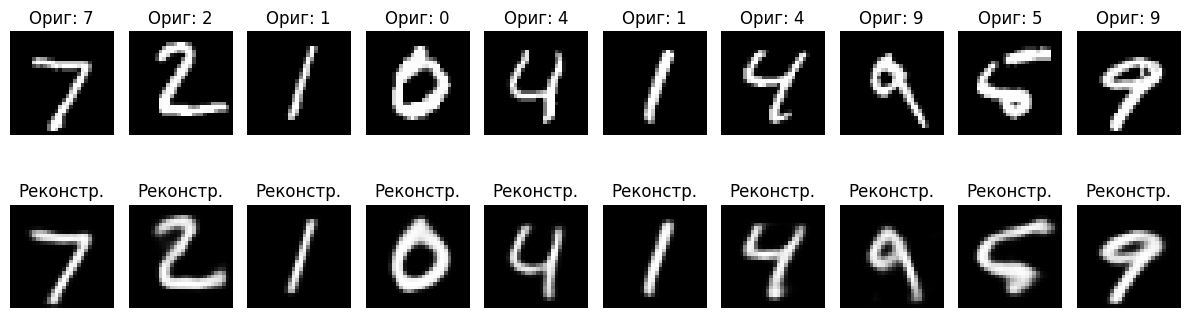


Эпоха 2/10
Батч [100/1875], Потери: 112.1703
Батч [200/1875], Потери: 113.8321
Батч [300/1875], Потери: 105.1241
Батч [400/1875], Потери: 93.5459
Батч [500/1875], Потери: 105.5555
Батч [600/1875], Потери: 101.0101
Батч [700/1875], Потери: 106.6025
Батч [800/1875], Потери: 110.8932
Батч [900/1875], Потери: 99.7680
Батч [1000/1875], Потери: 98.4527
Батч [1100/1875], Потери: 107.5898
Батч [1200/1875], Потери: 106.3362
Батч [1300/1875], Потери: 97.2278
Батч [1400/1875], Потери: 98.5561
Батч [1500/1875], Потери: 103.8766
Батч [1600/1875], Потери: 110.1865
Батч [1700/1875], Потери: 110.5272
Батч [1800/1875], Потери: 99.2564
Потери на обучении: 105.1894, на валидации: 93.5382


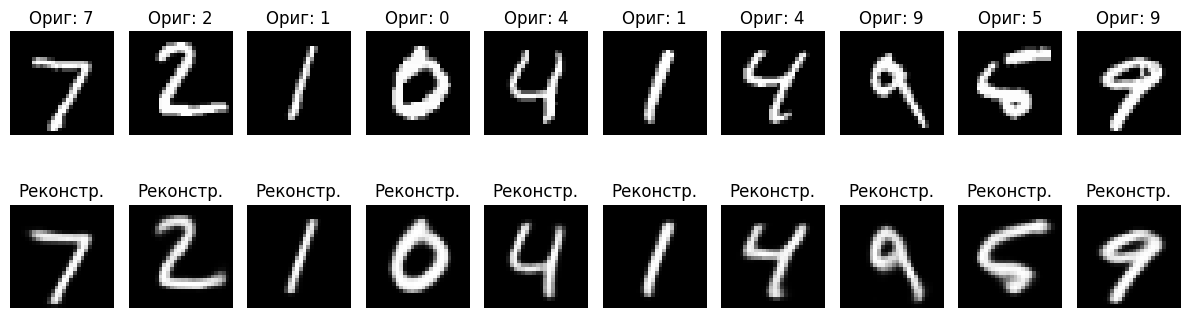


Эпоха 3/10
Батч [100/1875], Потери: 100.0944
Батч [200/1875], Потери: 105.2429
Батч [300/1875], Потери: 102.1573
Батч [400/1875], Потери: 101.1904
Батч [500/1875], Потери: 115.2094
Батч [600/1875], Потери: 105.4963
Батч [700/1875], Потери: 97.3891
Батч [800/1875], Потери: 103.4895
Батч [900/1875], Потери: 109.2214
Батч [1000/1875], Потери: 103.4961
Батч [1100/1875], Потери: 107.9535
Батч [1200/1875], Потери: 101.0330
Батч [1300/1875], Потери: 99.1798
Батч [1400/1875], Потери: 101.6465
Батч [1500/1875], Потери: 97.2628
Батч [1600/1875], Потери: 97.3884
Батч [1700/1875], Потери: 100.9020
Батч [1800/1875], Потери: 103.3925
Потери на обучении: 103.1971, на валидации: 92.2728

Эпоха 4/10
Батч [100/1875], Потери: 103.3409
Батч [200/1875], Потери: 105.5328
Батч [300/1875], Потери: 104.3575
Батч [400/1875], Потери: 104.3872
Батч [500/1875], Потери: 100.3351
Батч [600/1875], Потери: 102.8850
Батч [700/1875], Потери: 91.8189
Батч [800/1875], Потери: 101.2356
Батч [900/1875], Потери: 112.2880
Ба

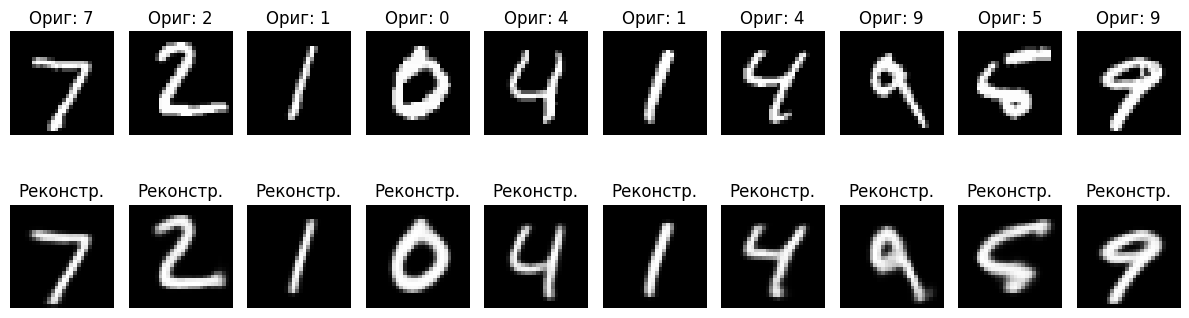


Эпоха 5/10
Батч [100/1875], Потери: 100.7733
Батч [200/1875], Потери: 98.9917
Батч [300/1875], Потери: 108.3050
Батч [400/1875], Потери: 99.5060
Батч [500/1875], Потери: 102.0357
Батч [600/1875], Потери: 91.7490
Батч [700/1875], Потери: 105.0331
Батч [800/1875], Потери: 98.5956
Батч [900/1875], Потери: 106.0248
Батч [1000/1875], Потери: 93.8548
Батч [1100/1875], Потери: 111.8656
Батч [1200/1875], Потери: 105.1836
Батч [1300/1875], Потери: 100.8558
Батч [1400/1875], Потери: 102.6674
Батч [1500/1875], Потери: 105.3689
Батч [1600/1875], Потери: 103.3078
Батч [1700/1875], Потери: 103.3211
Батч [1800/1875], Потери: 102.8049
Потери на обучении: 100.9169, на валидации: 91.3622

Эпоха 6/10
Батч [100/1875], Потери: 100.4374
Батч [200/1875], Потери: 94.2514
Батч [300/1875], Потери: 96.5753
Батч [400/1875], Потери: 99.4111
Батч [500/1875], Потери: 97.2648
Батч [600/1875], Потери: 93.8304
Батч [700/1875], Потери: 101.9868
Батч [800/1875], Потери: 106.7307
Батч [900/1875], Потери: 101.3257
Батч [1

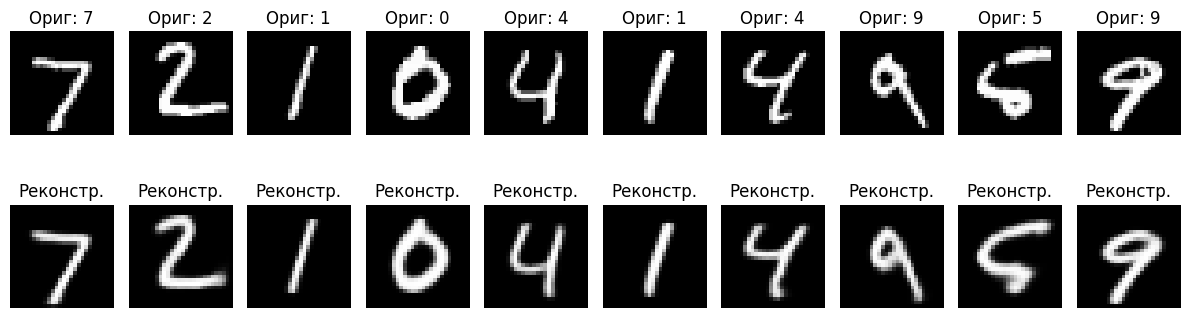


Эпоха 7/10
Батч [100/1875], Потери: 97.9596
Батч [200/1875], Потери: 102.0579
Батч [300/1875], Потери: 91.6652
Батч [400/1875], Потери: 105.5704
Батч [500/1875], Потери: 96.5760
Батч [600/1875], Потери: 98.8019
Батч [700/1875], Потери: 104.4482
Батч [800/1875], Потери: 102.3209
Батч [900/1875], Потери: 98.9387
Батч [1000/1875], Потери: 99.6103
Батч [1100/1875], Потери: 89.8371
Батч [1200/1875], Потери: 101.8494
Батч [1300/1875], Потери: 103.9237
Батч [1400/1875], Потери: 93.9036
Батч [1500/1875], Потери: 93.2303
Батч [1600/1875], Потери: 100.5209
Батч [1700/1875], Потери: 93.9635
Батч [1800/1875], Потери: 101.4307
Потери на обучении: 99.5534, на валидации: 91.2982

Эпоха 8/10
Батч [100/1875], Потери: 93.4841
Батч [200/1875], Потери: 102.8163
Батч [300/1875], Потери: 99.3232
Батч [400/1875], Потери: 101.3632
Батч [500/1875], Потери: 102.3260
Батч [600/1875], Потери: 95.1707
Батч [700/1875], Потери: 98.8964
Батч [800/1875], Потери: 92.7271
Батч [900/1875], Потери: 96.3613
Батч [1000/187

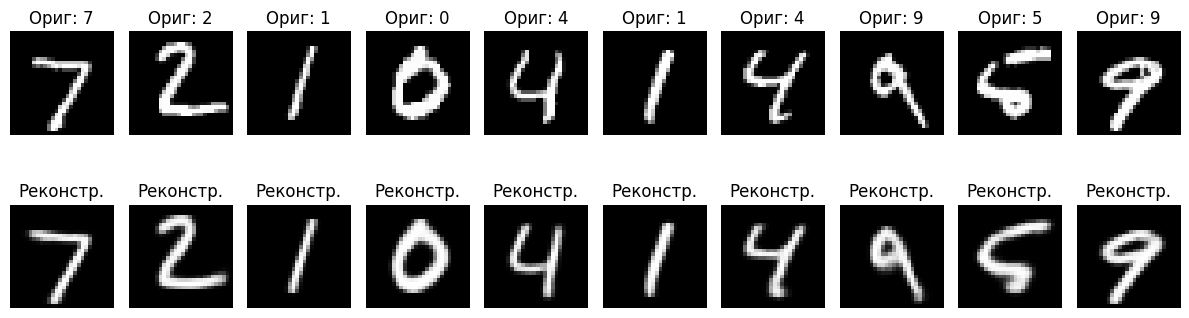


Эпоха 9/10
Батч [100/1875], Потери: 99.7247
Батч [200/1875], Потери: 97.5252
Батч [300/1875], Потери: 104.8376
Батч [400/1875], Потери: 98.6132
Батч [500/1875], Потери: 97.8387
Батч [600/1875], Потери: 93.1894
Батч [700/1875], Потери: 97.3275
Батч [800/1875], Потери: 103.4440
Батч [900/1875], Потери: 93.2686
Батч [1000/1875], Потери: 99.4445
Батч [1100/1875], Потери: 92.9411
Батч [1200/1875], Потери: 96.7492
Батч [1300/1875], Потери: 98.5726
Батч [1400/1875], Потери: 101.9234
Батч [1500/1875], Потери: 96.5035
Батч [1600/1875], Потери: 101.2298
Батч [1700/1875], Потери: 99.8235
Батч [1800/1875], Потери: 97.0021
Потери на обучении: 98.5683, на валидации: 89.7068

Эпоха 10/10
Батч [100/1875], Потери: 99.1761
Батч [200/1875], Потери: 98.4529
Батч [300/1875], Потери: 93.1845
Батч [400/1875], Потери: 102.0349
Батч [500/1875], Потери: 100.6019
Батч [600/1875], Потери: 96.3110
Батч [700/1875], Потери: 109.6373
Батч [800/1875], Потери: 106.6490
Батч [900/1875], Потери: 99.9004
Батч [1000/1875]

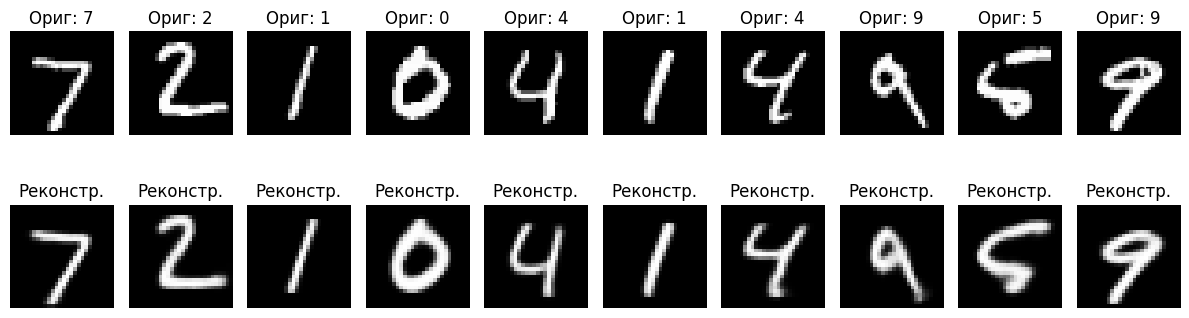

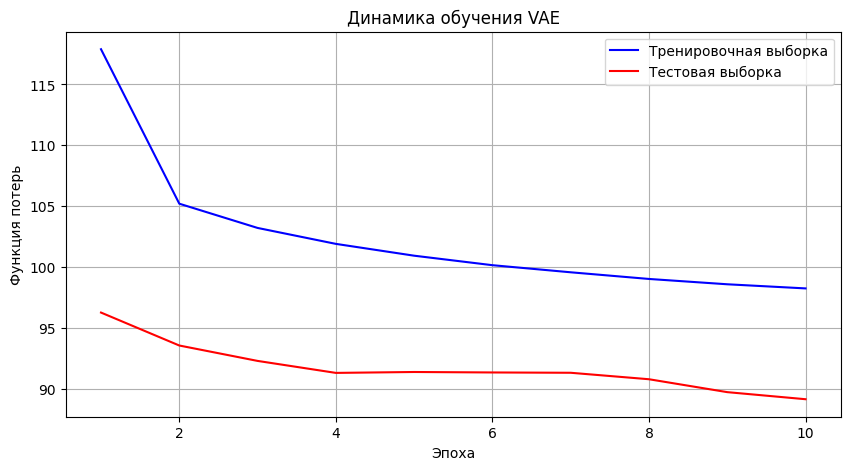

Модель сохранена как 'vae_mnist.pth'
Финальные результаты реконструкции:


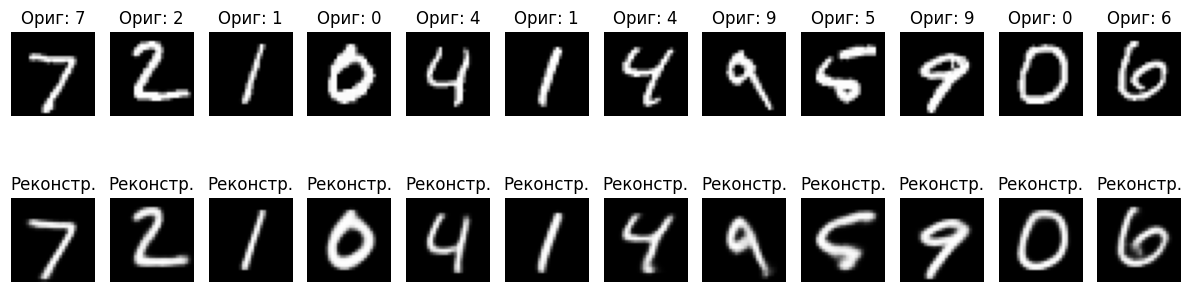

In [44]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    # Используя формулу KL-дивергенции из условия
    # D_KL = -0.5 * sum(1 + log(σ²) - μ² - σ²)
    # logsigma - это уже логарифм дисперсии log(σ²)
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    # Бинарная кросс-энтропия подходит для MNIST, т.к. значения пикселей близки к бинарным
    loss = F.binary_cross_entropy(reconstruction, x, reduction='sum')
    return loss

def loss_vae(x, mu, logsigma, reconstruction):
    # Соединяем две компоненты: log-likelihood и KL-дивергенцию
    # В формуле L = -D_KL(q_φ(z|x)||p(z)) + log p_θ(x|z)
    # Знак минус уже учтен в функции KL_divergence
    return log_likelihood(x, reconstruction) + KL_divergence(mu, logsigma)


# И обучим модель:
criterion = loss_vae

# Создаем экземпляр модели с размерностью латентного пространства 20
autoencoder = VAE(latent_dim=20)

# Используем Adam - хороший выбор для сложных архитектур
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3, weight_decay=1e-5)

# Определим устройство для обучения
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

# Перемещаем модель на устройство
autoencoder = autoencoder.to(device)

# Параметры обучения
num_epochs = 10  # Можно увеличить для лучших результатов
train_losses = []
val_losses = []

# Функция для обучения модели на одной эпохе
def train_epoch(model, train_loader, optimizer, device):
    model.train()
    epoch_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        # Переносим данные на устройство
        data = data.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        mu, logsigma, reconstruction = model(data)

        # Вычисляем функцию потерь
        loss = criterion(data, mu, logsigma, reconstruction)

        # Обратное распространение ошибки
        loss.backward()

        # Обновляем веса
        optimizer.step()

        # Накапливаем потери
        epoch_loss += loss.item()

        # Выводим промежуточный результат
        if (batch_idx + 1) % 100 == 0:
            print(f"Батч [{batch_idx+1}/{len(train_loader)}], Потери: {loss.item()/len(data):.4f}")

    # Средняя потеря за эпоху
    avg_loss = epoch_loss / len(train_loader.dataset)
    return avg_loss

# Функция для оценки модели на тестовом наборе
def validate(model, test_loader, device):
    model.eval()
    val_loss = 0

    with torch.no_grad():  # Отключаем вычисление градиентов
        for data, _ in test_loader:
            data = data.to(device)

            # Прямой проход
            mu, logsigma, reconstruction = model(data)

            # Вычисляем потери
            loss = criterion(data, mu, logsigma, reconstruction)

            # Накапливаем потери
            val_loss += loss.item()

    # Средняя потеря
    avg_loss = val_loss / len(test_loader.dataset)
    return avg_loss

# Визуализация реконструкций
def visualize_reconstructions(model, data_loader, device, num_samples=10):
    model.eval()

    # Получаем батч изображений
    dataiter = iter(data_loader)
    images, labels = next(dataiter)
    images = images[:num_samples].to(device)

    # Получаем реконструкции
    with torch.no_grad():
        mu, logsigma, recons = model(images)

    # Конвертируем тензоры в numpy для отображения
    images = images.cpu().numpy()
    recons = recons.cpu().numpy()

    # Создаем фигуру для отображения
    plt.figure(figsize=(12, 4))

    # Оригинальные изображения
    for i in range(num_samples):
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # [0] т.к. у нас одноканальные изображения
        plt.title(f"Ориг: {labels[i].item()}")
        plt.axis('off')

    # Реконструкции
    for i in range(num_samples):
        plt.subplot(2, num_samples, num_samples + i + 1)
        plt.imshow(recons[i][0], cmap='gray')
        plt.title("Реконстр.")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Основной цикл обучения
print("Начинаем обучение VAE...")
for epoch in range(1, num_epochs + 1):
    print(f"\nЭпоха {epoch}/{num_epochs}")

    # Обучение на тренировочном наборе
    train_loss = train_epoch(autoencoder, train_loader, optimizer, device)
    train_losses.append(train_loss)

    # Оценка на тестовом наборе
    val_loss = validate(autoencoder, test_loader, device)
    val_losses.append(val_loss)

    print(f"Потери на обучении: {train_loss:.4f}, на валидации: {val_loss:.4f}")

    # Визуализируем результаты после каждых 2 эпох
    if epoch % 2 == 0 or epoch == 1:
        visualize_reconstructions(autoencoder, test_loader, device)

# График потерь
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, 'b-', label='Тренировочная выборка')
plt.plot(range(1, num_epochs + 1), val_losses, 'r-', label='Тестовая выборка')
plt.xlabel('Эпоха')
plt.ylabel('Функция потерь')
plt.title('Динамика обучения VAE')
plt.legend()
plt.grid(True)
plt.show()

# Сохраняем обученную модель
torch.save(autoencoder.state_dict(), 'vae_mnist.pth')
print("Модель сохранена как 'vae_mnist.pth'")

# Финальная визуализация
print("Финальные результаты реконструкции:")
visualize_reconstructions(autoencoder, test_loader, device, num_samples=12)

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

Визуализация реконструкций VAE:


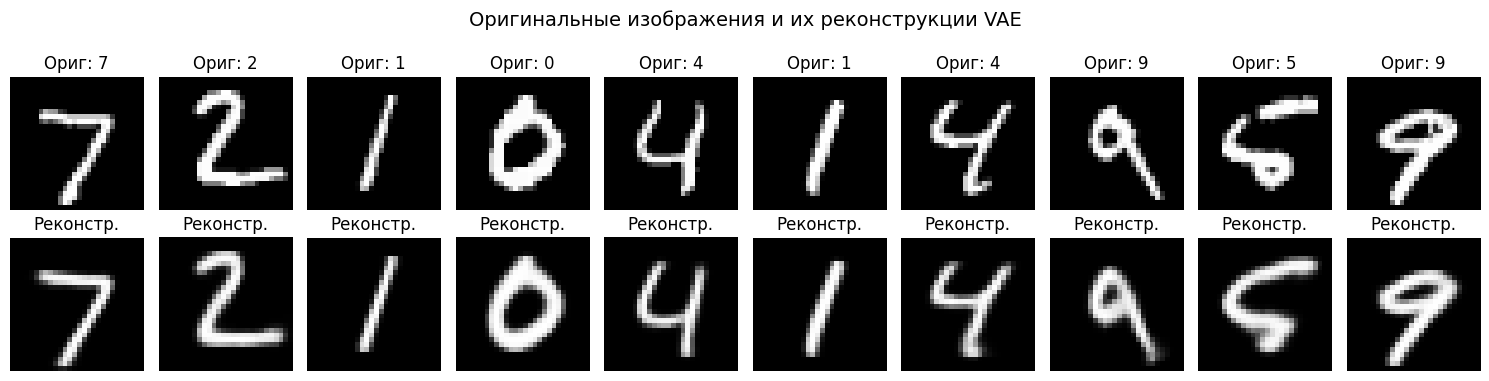

In [45]:
# Визуализация оригиналов и реконструкций из тестовой выборки
def show_reconstructions(model, test_loader, num_examples=12):
    # Переключаем модель в режим оценки
    model.eval()

    # Получаем устройство модели
    device = next(model.parameters()).device

    # Получаем батч изображений из загрузчика данных
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    # Ограничиваем количество примеров
    images = images[:num_examples].to(device)
    labels = labels[:num_examples]

    # Прогоняем изображения через модель
    with torch.no_grad():  # Отключаем вычисление градиентов
        mu, logsigma, reconstructions = model(images)

    # Переносим тензоры на CPU и преобразуем в numpy
    images = images.cpu().numpy()
    reconstructions = reconstructions.cpu().numpy()

    # Создаем сетку изображений: верхний ряд - оригиналы, нижний - реконструкции
    plt.figure(figsize=(15, 4))

    # Отображаем оригинальные изображения
    for i in range(num_examples):
        plt.subplot(2, num_examples, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # [0] - канал изображения (MNIST одноканальный)
        plt.title(f"Ориг: {labels[i].item()}")
        plt.axis('off')

    # Отображаем реконструкции
    for i in range(num_examples):
        plt.subplot(2, num_examples, num_examples + i + 1)
        plt.imshow(reconstructions[i][0], cmap='gray')
        plt.title("Реконстр.")
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle("Оригинальные изображения и их реконструкции VAE", fontsize=14)
    plt.subplots_adjust(top=0.85)
    plt.show()

# Визуализируем реконструкции с помощью нашей обученной модели
print("Визуализация реконструкций VAE:")
show_reconstructions(autoencoder, test_loader, num_examples=10)

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

Генерация изображений из случайных векторов в латентном пространстве:


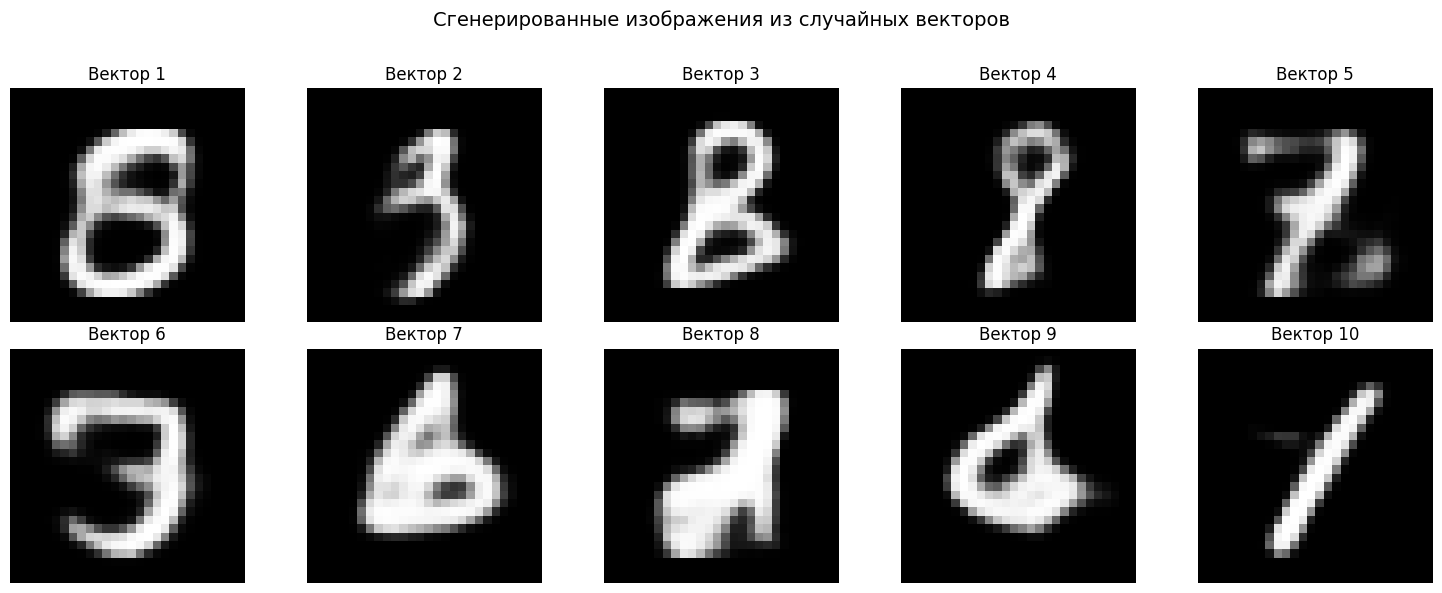

In [46]:
# Генерация изображений из случайных векторов в латентном пространстве
def generate_from_random_vectors(model, device=None):
    # Определяем устройство
    if device is None:
        device = next(model.parameters()).device

    # Переводим модель в режим оценки
    model.eval()

    # Получаем размерность латентного пространства из модели
    latent_dim = model.latent_dim

    # Создаем случайные векторы из стандартного нормального распределения
    # Важно использовать правильную размерность латентного пространства!
    z = np.array([np.random.normal(0, 1, latent_dim) for i in range(10)])

    # Преобразуем numpy массив в PyTorch тензор
    z_tensor = torch.FloatTensor(z).to(device)

    # Декодируем случайные векторы в изображения
    with torch.no_grad():  # Отключаем вычисление градиентов
        output = model.decode(z_tensor)

    # Преобразуем выходные тензоры в numpy массивы для визуализации
    output_images = output.cpu().numpy()

    # Визуализируем сгенерированные изображения
    plt.figure(figsize=(15, 6))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(output_images[i][0], cmap='gray')  # [0] - т.к. изображения одноканальные
        plt.title(f"Вектор {i+1}")
        plt.axis('off')

    plt.suptitle("Сгенерированные изображения из случайных векторов", fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

# Генерируем изображения из случайных векторов
print("Генерация изображений из случайных векторов в латентном пространстве:")
generate_from_random_vectors(autoencoder)

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

Визуализация латентного пространства MNIST с помощью t-SNE:
Получено 10000 латентных векторов размерности 20
Применяем t-SNE для снижения размерности...


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


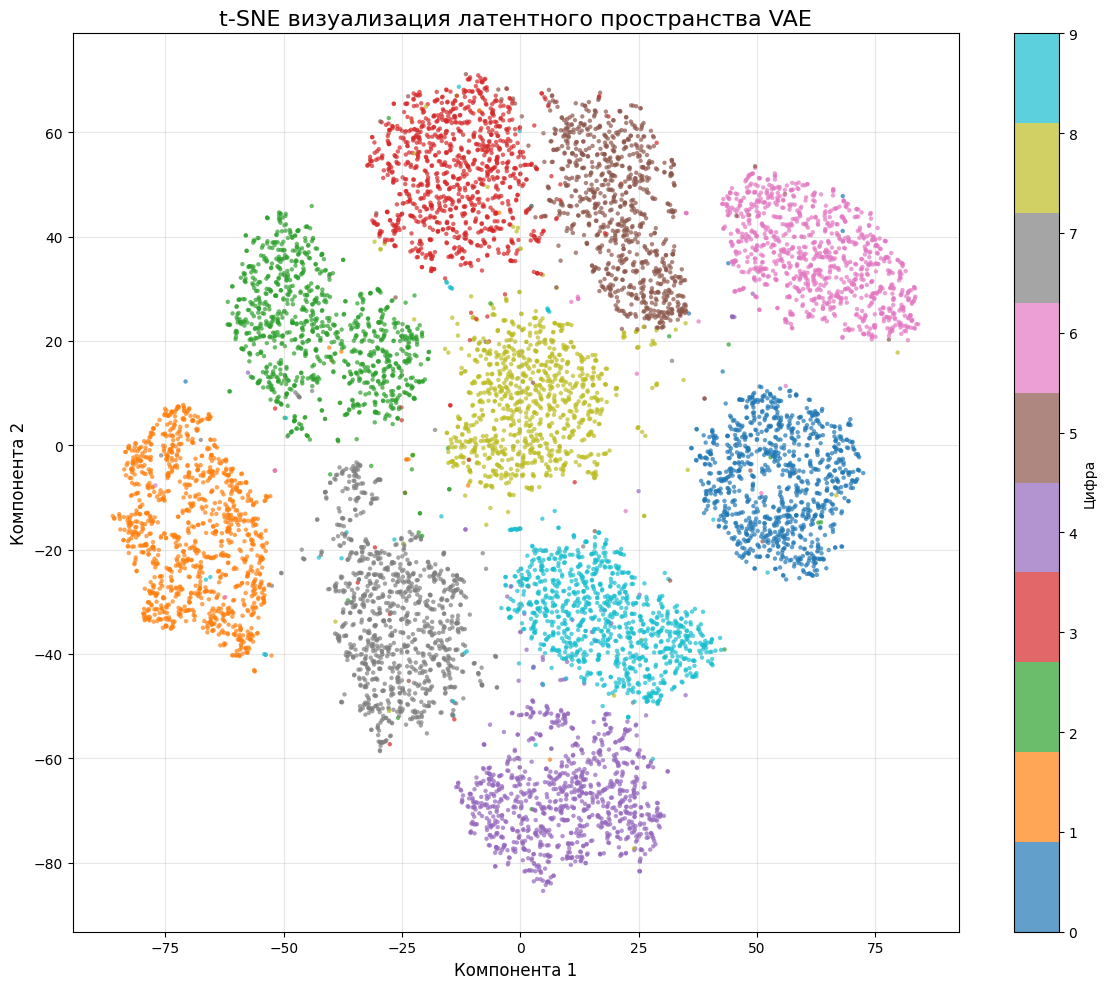

In [47]:
# Визуализация латентного пространства с использованием t-SNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def visualize_latent_space_tsne(model, data_loader, device=None):
    """
    Визуализирует латентное пространство VAE, применяя t-SNE для снижения размерности
    до 2D и раскрашивая точки в соответствии с классами цифр
    """
    # Определяем устройство, если не указано
    if device is None:
        device = next(model.parameters()).device

    # Переключаем модель в режим оценки
    model.eval()

    # Списки для сохранения латентных векторов и меток
    latent_vectors = []
    labels = []

    # Проходим по тестовому датасету и получаем латентные векторы
    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)

            # Получаем только mu (среднее значение) из энкодера
            mu, _ = model.encode(data)

            # Сохраняем латентные векторы и метки
            latent_vectors.append(mu.cpu().numpy())
            labels.append(target.numpy())

    # Объединяем данные из всех батчей
    latent_vectors = np.vstack(latent_vectors)
    labels = np.concatenate(labels)

    print(f"Получено {len(latent_vectors)} латентных векторов размерности {latent_vectors.shape[1]}")

    # Применяем t-SNE для снижения размерности до 2D
    print("Применяем t-SNE для снижения размерности...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    latent_2d = tsne.fit_transform(latent_vectors)

    # Визуализируем результаты
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap='tab10',
                         alpha=0.7, s=10, edgecolors='none')

    # Добавляем легенду
    legend = plt.colorbar(scatter, ticks=range(10))
    legend.set_label('Цифра')

    plt.title('t-SNE визуализация латентного пространства VAE', fontsize=16)
    plt.xlabel('Компонента 1', fontsize=12)
    plt.ylabel('Компонента 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Визуализируем латентное пространство
print("Визуализация латентного пространства MNIST с помощью t-SNE:")
visualize_latent_space_tsne(autoencoder, test_loader, device)

Что вы думаете о виде латентного представления?

1. Кластеризация: Если визуализация показывает чёткое разделение цифр на отдельные кластеры, это означает, что VAE успешно выучил осмысленное представление данных, где похожие цифры расположены близко друг к другу в латентном пространстве.
2. Плавные переходы: Для хорошо обученного VAE характерно наличие плавных переходов между кластерами, что указывает на то, что модель усвоила непрерывную структуру данных.
3. Перекрытия кластеров: Некоторые цифры, которые похожи визуально (например, 3 и 8, или 1 и 7), могут иметь перекрывающиеся области в латентном пространстве, что логично отражает их визуальное сходство.
4. Плотность распределения: Равномерное распределение точек без больших пустых областей говорит о том, что VAE хорошо уловил структуру распределения данных.
5. Структура внутри кластеров: Интересно наблюдать, как внутри кластера одной цифры точки могут группироваться по вариациям написания (например, разные стили написания цифры 7).

Эта визуализация демонстрирует, как VAE создаёт осмысленное и структурированное латентное пространство, где геометрическая близость точек отражает визуальное сходство соответствующих изображений.

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [48]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=20, num_classes=10):
        super(CVAE, self).__init__()

        # Сохраняем размерности
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # Размеры входных и промежуточных слоев
        self.input_dim = 784  # 28*28 (размер MNIST изображения)
        self.hidden_dim = 400  # Скрытый слой

        # Определяем архитектуру энкодера
        # Входной размер: изображение (784) + one-hot класс (10) = 794
        self.encoder_fc1 = nn.Linear(self.input_dim + self.num_classes, self.hidden_dim)

        # Два "хвоста" энкодера - для mu и logsigma
        self.fc_mu = nn.Linear(self.hidden_dim, self.latent_dim)
        self.fc_logsigma = nn.Linear(self.hidden_dim, self.latent_dim)

        # Определяем архитектуру декодера
        # Входной размер: латентный вектор (latent_dim) + one-hot класс (10)
        self.decoder_fc1 = nn.Linear(self.latent_dim + self.num_classes, self.hidden_dim)
        self.decoder_fc2 = nn.Linear(self.hidden_dim, self.input_dim)

    def encode(self, x, class_num):
        # Преобразуем класс в one-hot вектор
        one_hot = torch.zeros(x.size(0), self.num_classes, device=x.device)
        one_hot.scatter_(1, class_num.unsqueeze(1), 1)

        # Преобразуем изображение в плоский вектор
        x = x.view(-1, self.input_dim)

        # Конкатенируем изображение и one-hot вектор класса
        x_c = torch.cat([x, one_hot], dim=1)

        # Прогоняем через общий слой
        h1 = F.relu(self.encoder_fc1(x_c))

        # Вычисляем mu и logsigma
        mu = self.fc_mu(h1)
        logsigma = self.fc_logsigma(h1)

        return mu, logsigma, class_num

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # Трюк с репараметризацией для обучения
            # Семплируем eps из N(0, I)
            eps = torch.randn_like(mu)

            # Преобразуем в нужное распределение
            # z = mu + sigma * eps
            std = torch.exp(0.5 * logsigma)
            z = mu + eps * std
            return z
        else:
            # На инференсе возвращаем детерминированное значение
            return mu

    def decode(self, z, class_num):
        # Преобразуем класс в one-hot вектор
        one_hot = torch.zeros(z.size(0), self.num_classes, device=z.device)
        one_hot.scatter_(1, class_num.unsqueeze(1), 1)

        # Конкатенируем латентный вектор и one-hot вектор класса
        z_c = torch.cat([z, one_hot], dim=1)

        # Декодируем
        h2 = F.relu(self.decoder_fc1(z_c))
        reconstruction = torch.sigmoid(self.decoder_fc2(h2))

        # Преобразуем в формат изображения
        reconstruction = reconstruction.view(-1, 1, 28, 28)

        return reconstruction

    def forward(self, x, class_num=None):
        # Если класс не передан, пытаемся предсказать его
        # В случае MNIST можно было бы добавить классификатор,
        # но здесь предполагаем, что класс всегда передается
        if class_num is None:
            raise ValueError("Для CVAE необходимо передать номер класса")

        # Получаем параметры распределения
        mu, logsigma, class_num = self.encode(x, class_num)

        # Семплируем из латентного пространства
        z = self.gaussian_sampler(mu, logsigma)

        # Декодируем латентный вектор в изображение
        reconstruction = self.decode(z, class_num)

        return mu, logsigma, reconstruction

Эпоха 1/10
Батч [100/1875], Потери: 188.2238
Батч [200/1875], Потери: 167.9446
Батч [300/1875], Потери: 129.2489
Батч [400/1875], Потери: 135.2060
Батч [500/1875], Потери: 139.6249
Батч [600/1875], Потери: 132.0800
Батч [700/1875], Потери: 123.9261
Батч [800/1875], Потери: 122.6813
Батч [900/1875], Потери: 119.8555
Батч [1000/1875], Потери: 124.3910
Батч [1100/1875], Потери: 122.0774
Батч [1200/1875], Потери: 111.8691
Батч [1300/1875], Потери: 119.0837
Батч [1400/1875], Потери: 115.3048
Батч [1500/1875], Потери: 117.3645
Батч [1600/1875], Потери: 116.2071
Батч [1700/1875], Потери: 113.2405
Батч [1800/1875], Потери: 102.9023
Средняя потеря: 133.4968


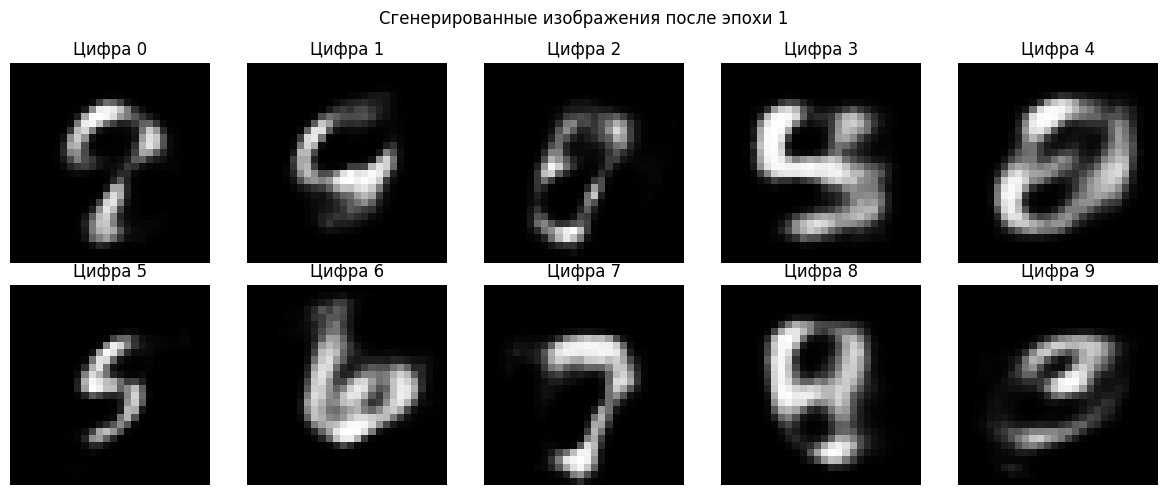

Эпоха 2/10
Батч [100/1875], Потери: 118.6015
Батч [200/1875], Потери: 105.2039
Батч [300/1875], Потери: 116.1702
Батч [400/1875], Потери: 113.7943
Батч [500/1875], Потери: 121.2653
Батч [600/1875], Потери: 113.7261
Батч [700/1875], Потери: 102.1958
Батч [800/1875], Потери: 116.8705
Батч [900/1875], Потери: 104.4580
Батч [1000/1875], Потери: 106.2464
Батч [1100/1875], Потери: 97.1826
Батч [1200/1875], Потери: 106.2735
Батч [1300/1875], Потери: 106.0886
Батч [1400/1875], Потери: 121.6469
Батч [1500/1875], Потери: 119.7239
Батч [1600/1875], Потери: 111.4194
Батч [1700/1875], Потери: 114.8367
Батч [1800/1875], Потери: 109.3078
Средняя потеря: 110.3806


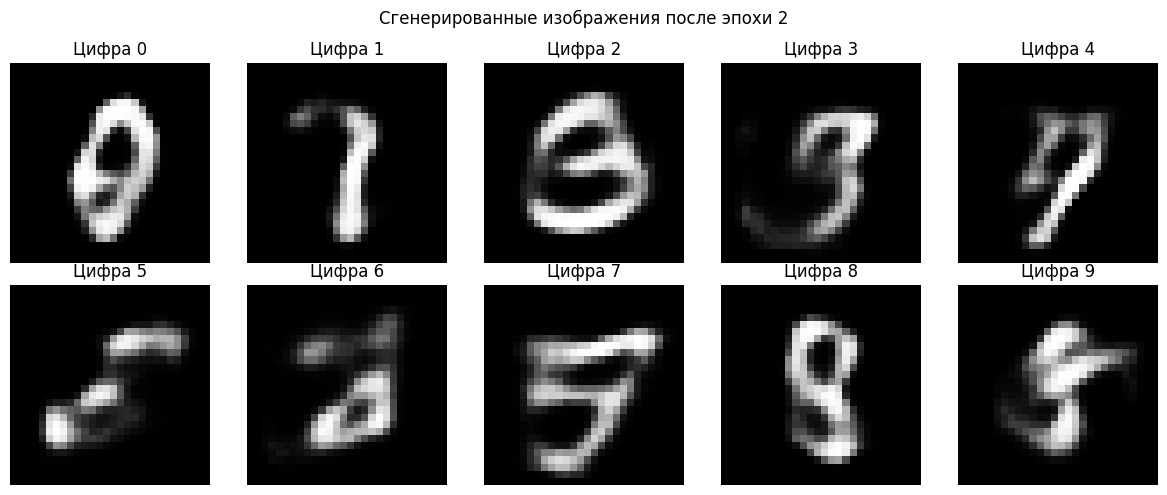

Эпоха 3/10
Батч [100/1875], Потери: 115.0649
Батч [200/1875], Потери: 109.9207
Батч [300/1875], Потери: 109.0230
Батч [400/1875], Потери: 109.5217
Батч [500/1875], Потери: 100.1789
Батч [600/1875], Потери: 109.8252
Батч [700/1875], Потери: 112.1052
Батч [800/1875], Потери: 109.3922
Батч [900/1875], Потери: 106.3413
Батч [1000/1875], Потери: 101.4227
Батч [1100/1875], Потери: 106.3598
Батч [1200/1875], Потери: 99.2451
Батч [1300/1875], Потери: 113.2715
Батч [1400/1875], Потери: 104.6047
Батч [1500/1875], Потери: 112.1960
Батч [1600/1875], Потери: 102.5651
Батч [1700/1875], Потери: 102.6533
Батч [1800/1875], Потери: 106.1701
Средняя потеря: 106.6998
Эпоха 4/10
Батч [100/1875], Потери: 108.5554
Батч [200/1875], Потери: 111.1295
Батч [300/1875], Потери: 109.8787
Батч [400/1875], Потери: 106.9754
Батч [500/1875], Потери: 102.6911
Батч [600/1875], Потери: 102.4338
Батч [700/1875], Потери: 105.3228
Батч [800/1875], Потери: 106.5622
Батч [900/1875], Потери: 107.3079
Батч [1000/1875], Потери: 1

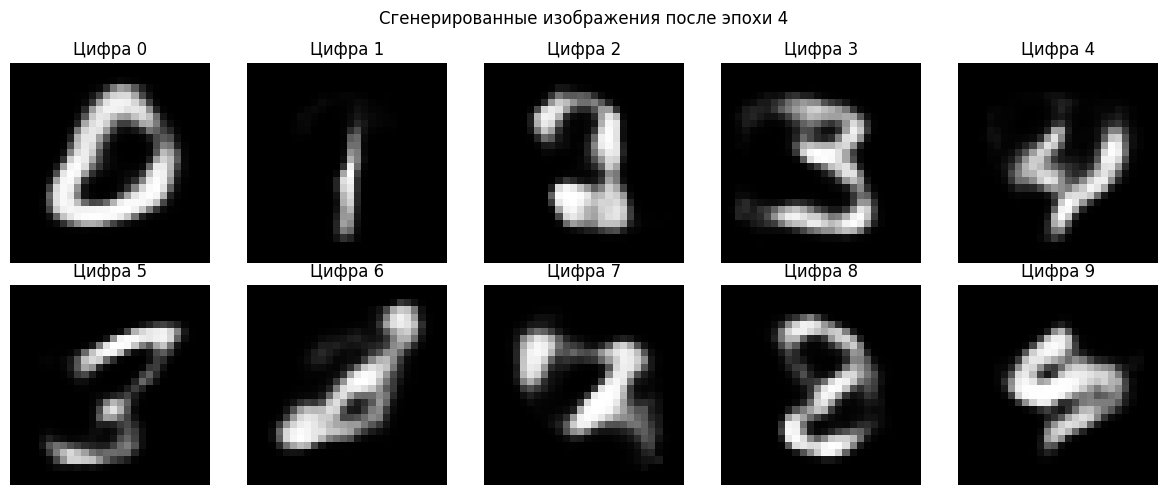

Эпоха 5/10
Батч [100/1875], Потери: 98.7607
Батч [200/1875], Потери: 99.5686
Батч [300/1875], Потери: 106.3406
Батч [400/1875], Потери: 101.1136
Батч [500/1875], Потери: 99.6747
Батч [600/1875], Потери: 102.9445
Батч [700/1875], Потери: 96.9935
Батч [800/1875], Потери: 100.9038
Батч [900/1875], Потери: 113.3559
Батч [1000/1875], Потери: 107.1344
Батч [1100/1875], Потери: 93.8514
Батч [1200/1875], Потери: 107.1393
Батч [1300/1875], Потери: 95.1318
Батч [1400/1875], Потери: 100.4563
Батч [1500/1875], Потери: 102.1167
Батч [1600/1875], Потери: 91.4148
Батч [1700/1875], Потери: 105.2709
Батч [1800/1875], Потери: 104.5463
Средняя потеря: 103.7003
Эпоха 6/10
Батч [100/1875], Потери: 110.9324
Батч [200/1875], Потери: 104.2757
Батч [300/1875], Потери: 111.0398
Батч [400/1875], Потери: 104.7733
Батч [500/1875], Потери: 106.3180
Батч [600/1875], Потери: 97.9490
Батч [700/1875], Потери: 107.6887
Батч [800/1875], Потери: 109.1852
Батч [900/1875], Потери: 100.8730
Батч [1000/1875], Потери: 108.5561

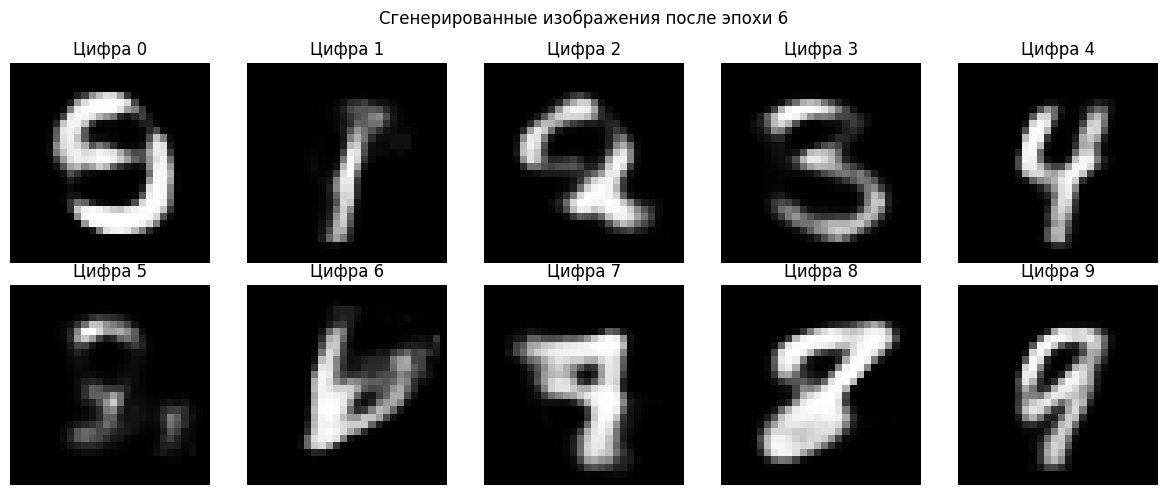

Эпоха 7/10
Батч [100/1875], Потери: 106.9179
Батч [200/1875], Потери: 107.5903
Батч [300/1875], Потери: 105.9007
Батч [400/1875], Потери: 102.9664
Батч [500/1875], Потери: 105.2681
Батч [600/1875], Потери: 96.1709
Батч [700/1875], Потери: 105.3179
Батч [800/1875], Потери: 104.3005
Батч [900/1875], Потери: 107.3740
Батч [1000/1875], Потери: 102.8113
Батч [1100/1875], Потери: 106.4910
Батч [1200/1875], Потери: 102.6178
Батч [1300/1875], Потери: 99.8412
Батч [1400/1875], Потери: 99.2248
Батч [1500/1875], Потери: 95.7860
Батч [1600/1875], Потери: 109.2285
Батч [1700/1875], Потери: 96.5450
Батч [1800/1875], Потери: 101.7945
Средняя потеря: 102.2982
Эпоха 8/10
Батч [100/1875], Потери: 91.1281
Батч [200/1875], Потери: 97.9580
Батч [300/1875], Потери: 108.8054
Батч [400/1875], Потери: 99.5303
Батч [500/1875], Потери: 90.1185
Батч [600/1875], Потери: 99.8666
Батч [700/1875], Потери: 102.0856
Батч [800/1875], Потери: 101.6200
Батч [900/1875], Потери: 104.0914
Батч [1000/1875], Потери: 100.1349
Б

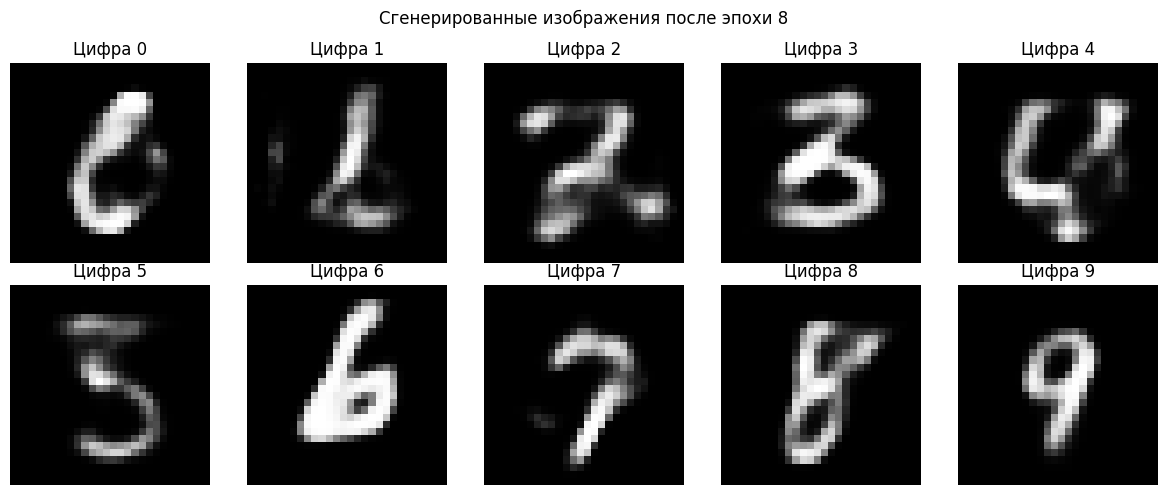

Эпоха 9/10
Батч [100/1875], Потери: 107.0037
Батч [200/1875], Потери: 100.9247
Батч [300/1875], Потери: 97.5993
Батч [400/1875], Потери: 97.9341
Батч [500/1875], Потери: 109.6549
Батч [600/1875], Потери: 100.3157
Батч [700/1875], Потери: 96.7265
Батч [800/1875], Потери: 95.9296
Батч [900/1875], Потери: 106.1504
Батч [1000/1875], Потери: 104.3464
Батч [1100/1875], Потери: 100.4598
Батч [1200/1875], Потери: 98.7591
Батч [1300/1875], Потери: 107.6674
Батч [1400/1875], Потери: 104.4744
Батч [1500/1875], Потери: 105.0990
Батч [1600/1875], Потери: 98.5297
Батч [1700/1875], Потери: 94.8090
Батч [1800/1875], Потери: 106.6253
Средняя потеря: 101.3834
Эпоха 10/10
Батч [100/1875], Потери: 102.6908
Батч [200/1875], Потери: 106.7198
Батч [300/1875], Потери: 93.9624
Батч [400/1875], Потери: 102.3015
Батч [500/1875], Потери: 96.9145
Батч [600/1875], Потери: 101.6257
Батч [700/1875], Потери: 107.8247
Батч [800/1875], Потери: 105.0037
Батч [900/1875], Потери: 109.1197
Батч [1000/1875], Потери: 101.9373

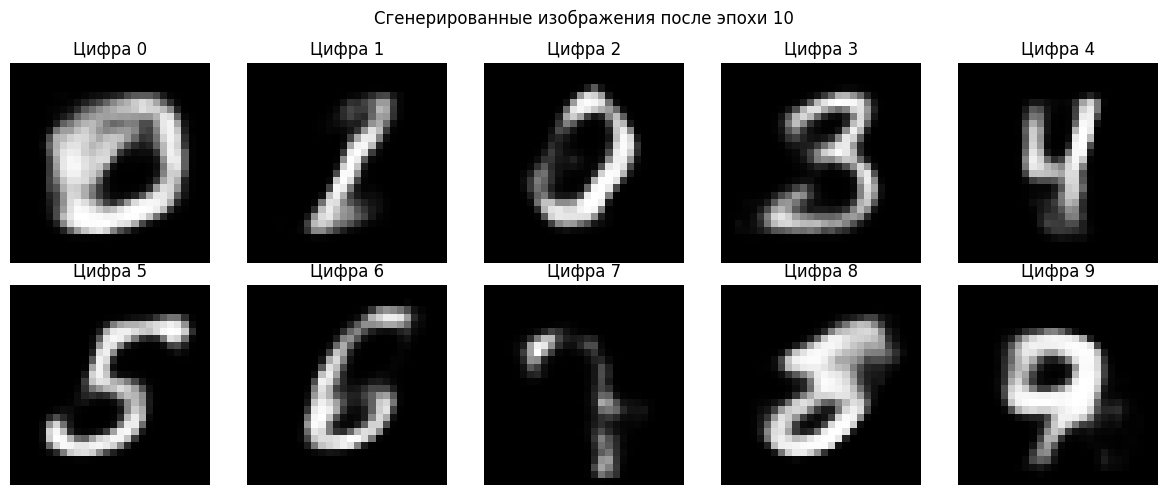

Модель CVAE сохранена как 'cvae_mnist.pth'


In [49]:
# Функция потерь для CVAE (аналогична VAE, но с учетом класса)
def loss_cvae(x, mu, logsigma, reconstruction):
    # Ошибка реконструкции (Binary Cross Entropy)
    BCE = F.binary_cross_entropy(reconstruction, x, reduction='sum')

    # KL-дивергенция между q(z|x,c) и p(z)
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())

    return BCE + KLD

# Обучение модели
cvae = CVAE(latent_dim=20, num_classes=10)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cvae = cvae.to(device)
optimizer = optim.Adam(cvae.parameters(), lr=1e-3)

# Функция для обучения на одной эпохе
def train_cvae_epoch(model, train_loader, optimizer, device):
    model.train()
    train_loss = 0

    for batch_idx, (data, targets) in enumerate(train_loader):
        data, targets = data.to(device), targets.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Вычисляем выход модели
        mu, logsigma, recon = model(data, targets)

        # Вычисляем функцию потерь
        loss = loss_cvae(data, mu, logsigma, recon)

        # Обратное распространение ошибки
        loss.backward()

        # Обновляем параметры
        optimizer.step()

        # Накапливаем потери
        train_loss += loss.item()

        # Выводим прогресс каждые 100 батчей
        if (batch_idx + 1) % 100 == 0:
            print(f"Батч [{batch_idx+1}/{len(train_loader)}], Потери: {loss.item()/len(data):.4f}")

    # Средняя потеря за эпоху
    avg_loss = train_loss / len(train_loader.dataset)
    return avg_loss

# Обучаем модель
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    print(f"Эпоха {epoch}/{num_epochs}")
    loss = train_cvae_epoch(cvae, train_loader, optimizer, device)
    print(f"Средняя потеря: {loss:.4f}")

    # Генерируем изображения каждой цифры после каждой эпохи
    if epoch % 2 == 0 or epoch == 1:
        # Визуализация генерируемых изображений
        with torch.no_grad():
            # Создаем случайные векторы для каждой цифры
            z = torch.randn(10, 20).to(device)

            # Для каждой цифры от 0 до 9
            samples = []
            for i in range(10):
                # Преобразуем в тензор
                digit = torch.tensor([i], device=device)

                # Генерируем изображение
                sample = cvae.decode(z[i:i+1], digit)
                samples.append(sample)

            # Объединяем все изображения
            samples = torch.cat(samples)

            # Визуализируем
            plt.figure(figsize=(12, 5))
            for i in range(10):
                plt.subplot(2, 5, i + 1)
                plt.imshow(samples[i].cpu().squeeze().numpy(), cmap='gray')
                plt.title(f"Цифра {i}")
                plt.axis('off')

            plt.suptitle(f"Сгенерированные изображения после эпохи {epoch}")
            plt.tight_layout()
            plt.show()

# Сохраняем обученную модель
torch.save(cvae.state_dict(), 'cvae_mnist.pth')
print("Модель CVAE сохранена как 'cvae_mnist.pth'")

Генерируем изображения цифры 0:


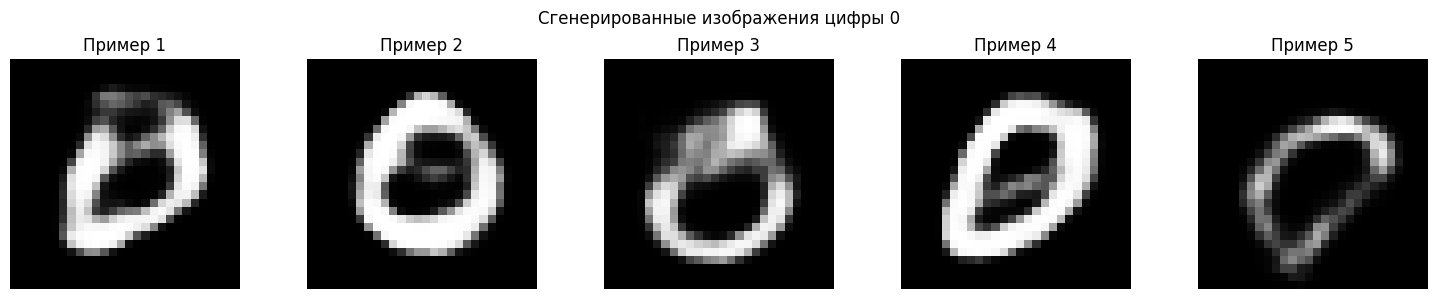

Генерируем изображения цифры 1:


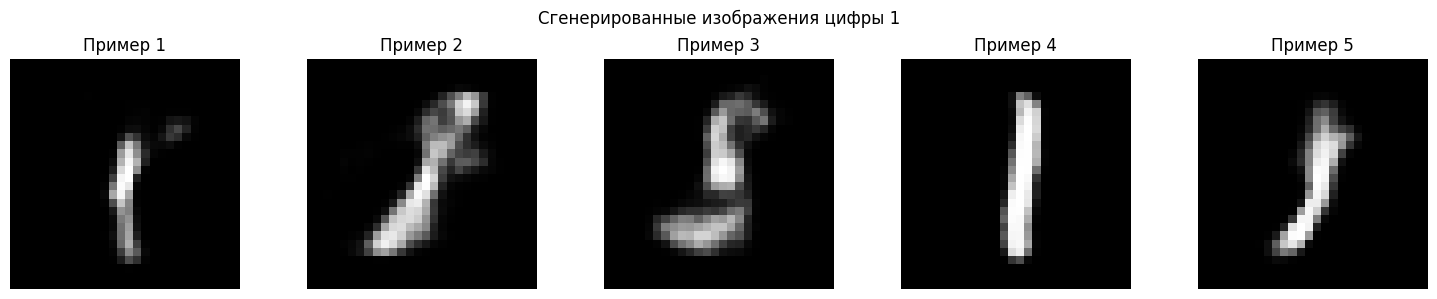

Генерируем изображения цифры 2:


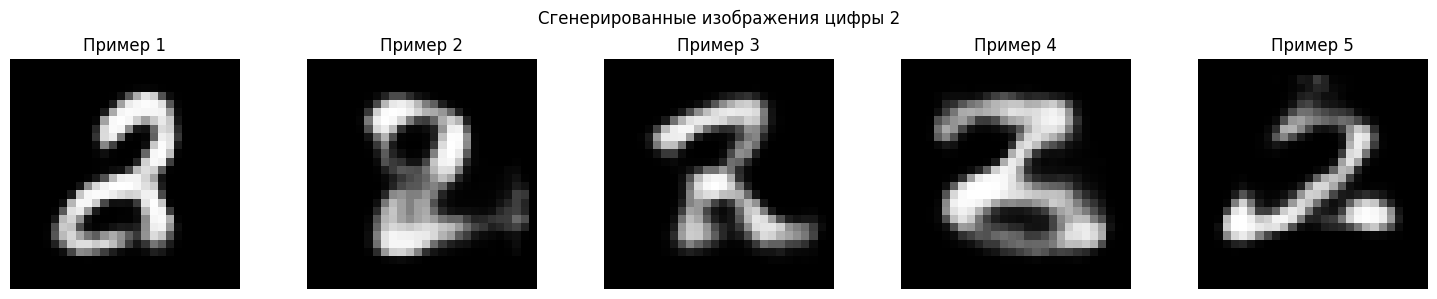

Генерируем изображения цифры 3:


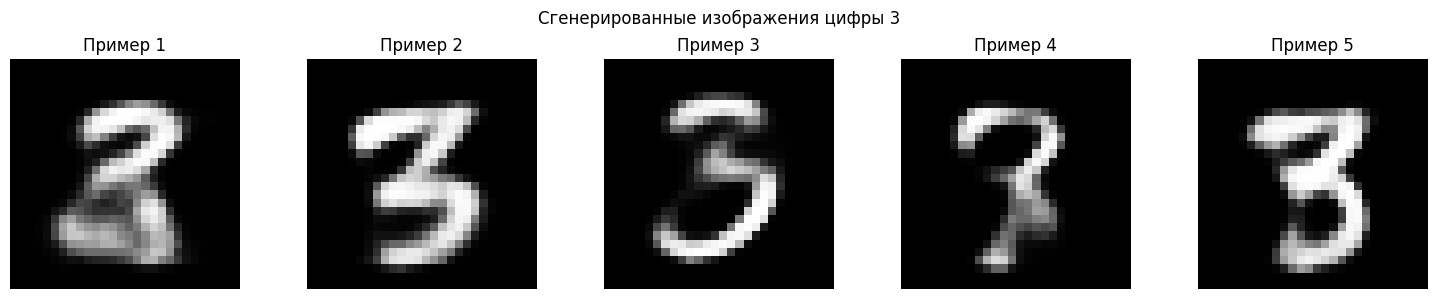

Генерируем изображения цифры 4:


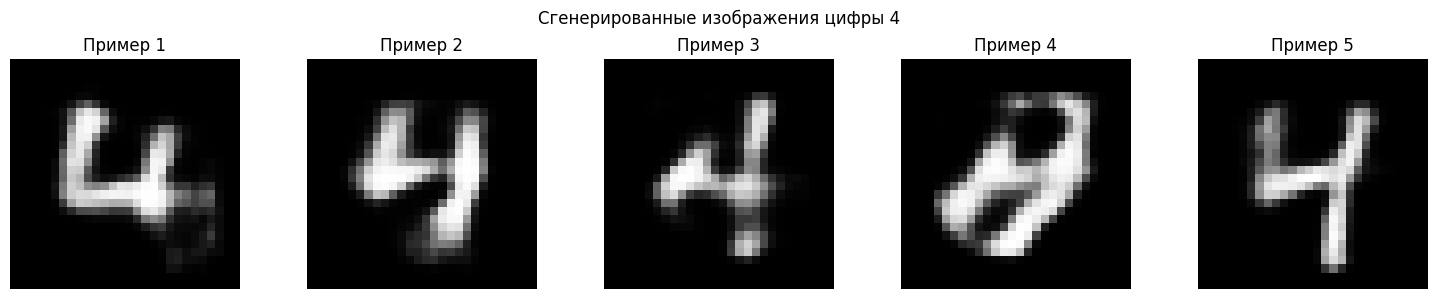

Генерируем изображения цифры 5:


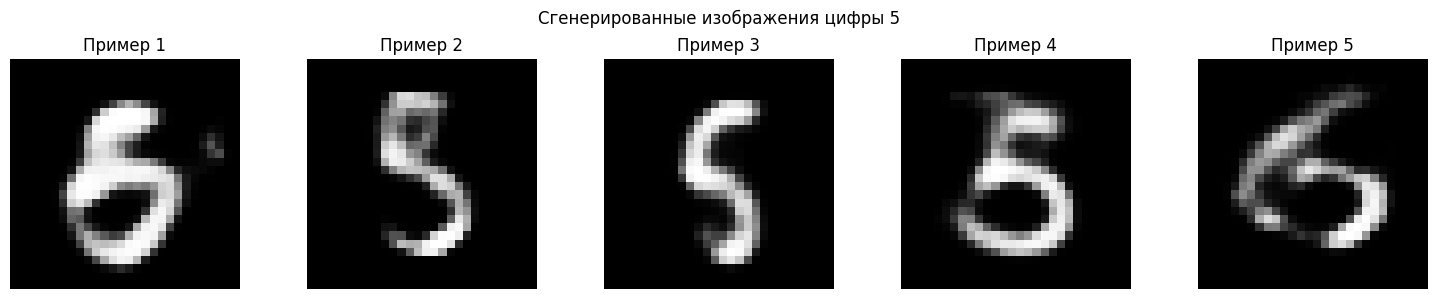

Генерируем изображения цифры 6:


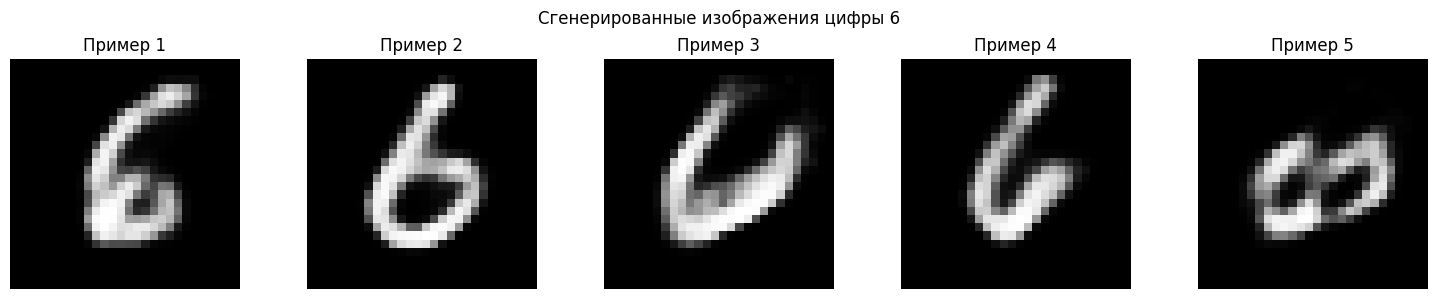

Генерируем изображения цифры 7:


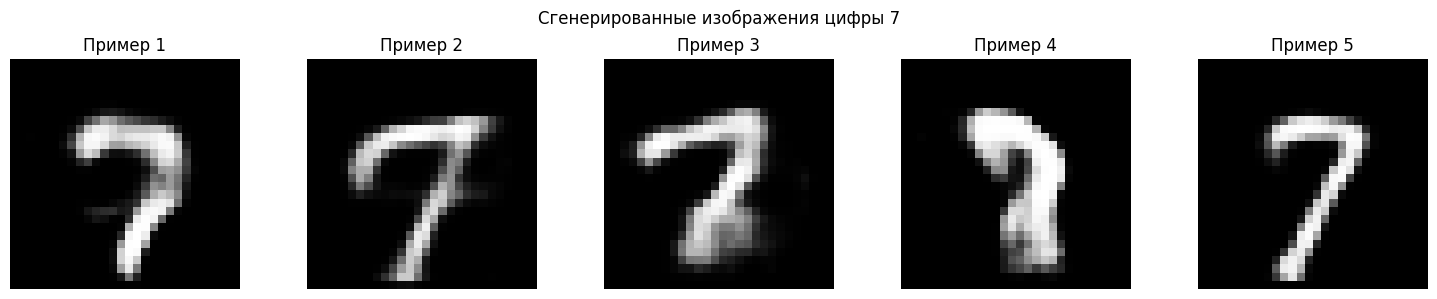

Генерируем изображения цифры 8:


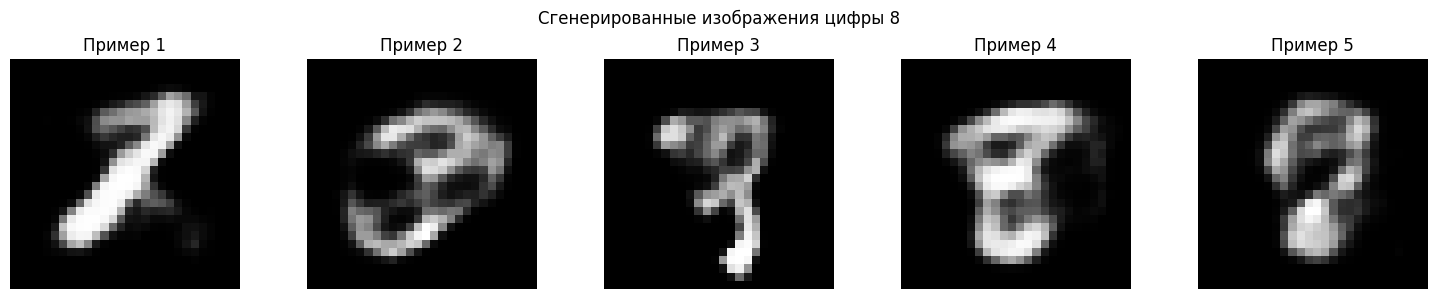

Генерируем изображения цифры 9:


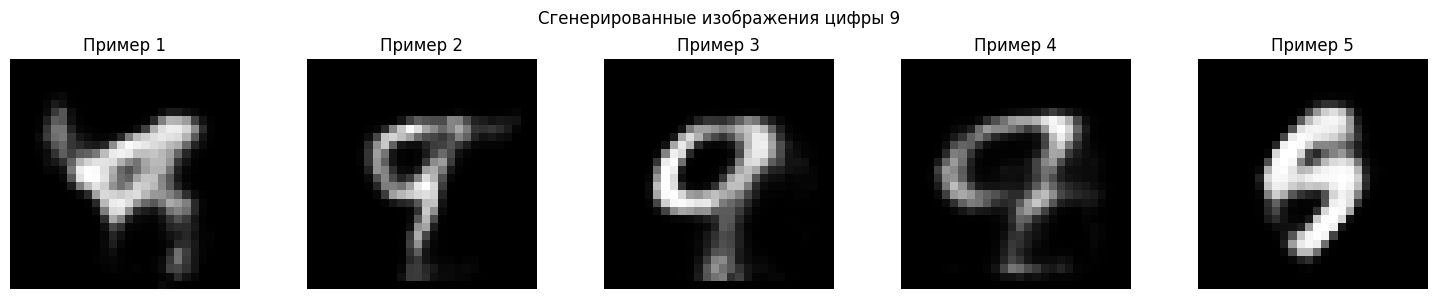

In [50]:
def generate_digit(model, digit, num_samples=5, device=None):
    """
    Генерирует изображения заданной цифры

    Args:
        model: обученная модель CVAE
        digit: цифра для генерации (от 0 до 9)
        num_samples: количество генерируемых изображений
        device: устройство для вычислений
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    # Создаем тензор с заданной цифрой
    digit_tensor = torch.full((num_samples,), digit, dtype=torch.long, device=device)

    # Создаем случайные векторы из латентного пространства
    z = torch.randn(num_samples, model.latent_dim, device=device)

    # Генерируем изображения
    with torch.no_grad():
        samples = model.decode(z, digit_tensor)

    # Визуализируем результаты
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(samples[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Пример {i+1}")
        plt.axis('off')

    plt.suptitle(f"Сгенерированные изображения цифры {digit}")
    plt.tight_layout()
    plt.show()

    return samples

# Генерируем по 5 примеров каждой цифры
for digit in range(10):
    print(f"Генерируем изображения цифры {digit}:")
    generate_digit(cvae, digit, num_samples=5, device=device)

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

Пример 1: Один латентный вектор → разные цифры


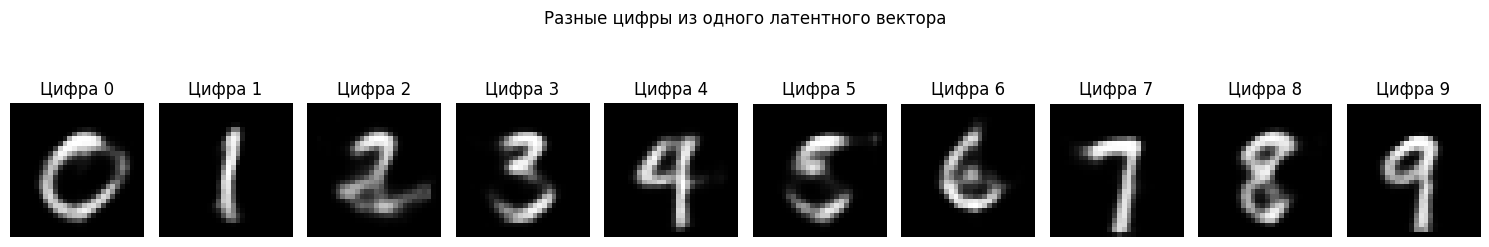

Пример 2: Другой латентный вектор → разные цифры


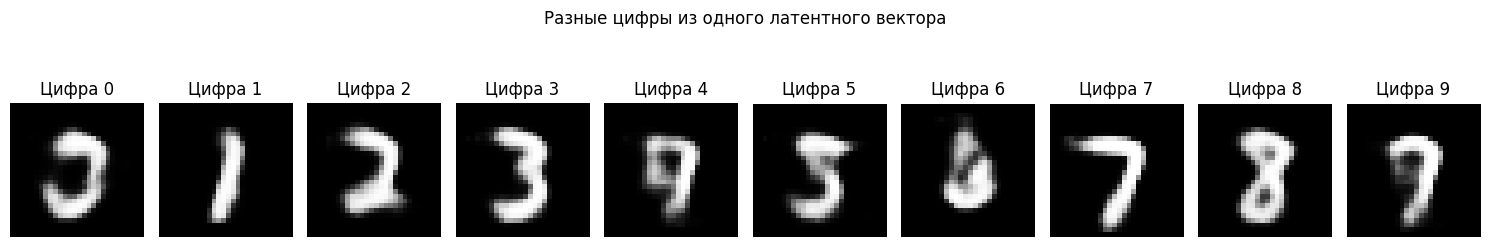

Пример 3: Ещё один латентный вектор → разные цифры


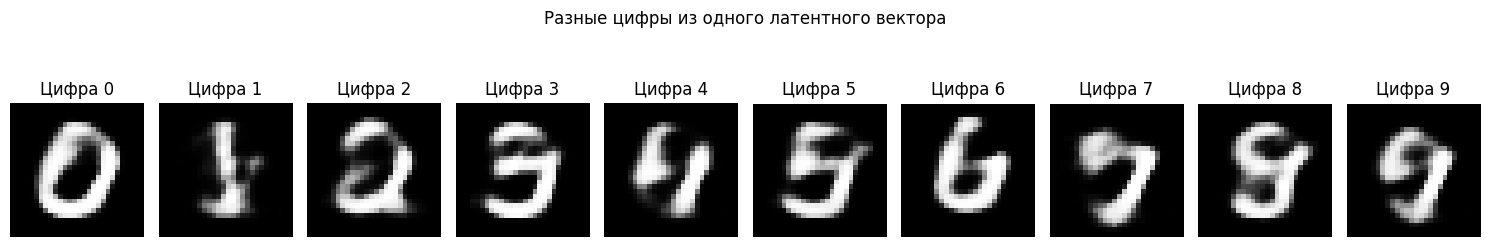

tensor([[[[1.4254e-09, 1.1670e-09, 4.3545e-10,  ..., 8.9967e-10,
           9.1995e-10, 1.0241e-09],
          [7.4951e-10, 6.9745e-10, 9.6350e-10,  ..., 8.8268e-10,
           1.0332e-09, 5.8206e-10],
          [7.9306e-10, 7.9111e-10, 3.6846e-10,  ..., 2.4397e-17,
           7.8106e-10, 7.3735e-10],
          ...,
          [9.8371e-10, 1.0897e-09, 4.2863e-13,  ..., 2.3209e-14,
           3.8123e-15, 7.4172e-10],
          [1.0298e-09, 7.1011e-10, 6.6208e-10,  ..., 3.6068e-14,
           7.1278e-10, 7.3704e-10],
          [1.2267e-09, 8.2615e-10, 6.1684e-10,  ..., 1.2922e-09,
           8.0268e-10, 6.6077e-10]]],


        [[[5.0558e-07, 3.6330e-07, 5.2121e-07,  ..., 5.4914e-07,
           4.8080e-07, 4.2178e-07],
          [4.3947e-07, 4.7069e-07, 4.0153e-07,  ..., 4.0488e-07,
           6.3898e-07, 2.9203e-07],
          [4.7480e-07, 3.7238e-07, 6.4238e-07,  ..., 4.1388e-11,
           4.0664e-07, 3.9996e-07],
          ...,
          [4.0108e-07, 5.2848e-07, 2.6868e-10,  ..., 2.95

In [51]:
# Функция для сэмплирования из CVAE с фиксированным латентным вектором
def sample_with_fixed_latent(model, latent_vector=None, device=None):
    """
    Генерирует изображения всех цифр, используя один и тот же латентный вектор

    Args:
        model: обученная модель CVAE
        latent_vector: фиксированный латентный вектор (если None, будет сгенерирован случайно)
        device: устройство для вычислений
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    # Если латентный вектор не передан, генерируем случайный
    if latent_vector is None:
        latent_vector = torch.randn(1, model.latent_dim, device=device)

    # Повторяем вектор для каждой цифры (от 0 до 9)
    latent_repeated = latent_vector.repeat(10, 1)

    # Создаем тензор с цифрами от 0 до 9
    digits = torch.arange(10, device=device)

    # Генерируем изображения
    with torch.no_grad():
        samples = model.decode(latent_repeated, digits)

    # Визуализируем результаты
    plt.figure(figsize=(15, 3))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(samples[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Цифра {i}")
        plt.axis('off')

    plt.suptitle("Разные цифры из одного латентного вектора")
    plt.tight_layout()
    plt.show()

    return samples

# Генерируем несколько примеров с разными латентными векторами
print("Пример 1: Один латентный вектор → разные цифры")
z1 = torch.randn(1, cvae.latent_dim, device=device)
sample_with_fixed_latent(cvae, latent_vector=z1, device=device)

print("Пример 2: Другой латентный вектор → разные цифры")
z2 = torch.randn(1, cvae.latent_dim, device=device)
sample_with_fixed_latent(cvae, latent_vector=z2, device=device)

print("Пример 3: Ещё один латентный вектор → разные цифры")
z3 = torch.randn(1, cvae.latent_dim, device=device)
sample_with_fixed_latent(cvae, latent_vector=z3, device=device)

Интерполяция для цифры 3:


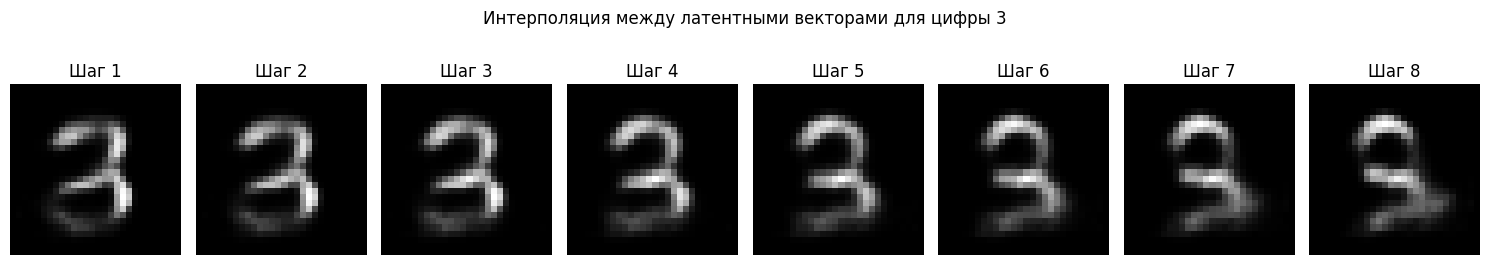

Интерполяция для цифры 7:


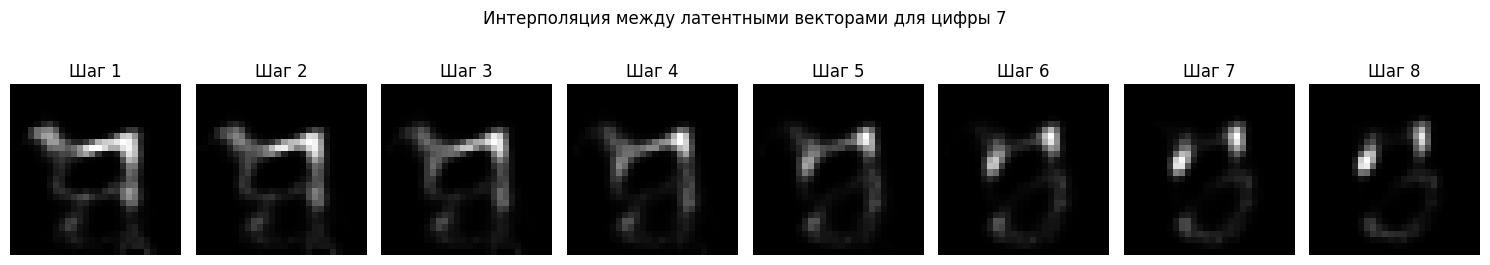

In [53]:
# Функция для интерполяции между двумя латентными векторами с фиксированным классом
def interpolate_latent_with_fixed_class(model, digit, num_steps=10, device=None):
    """
    Интерполирует между двумя случайными латентными векторами,
    генерируя изображения одной и той же цифры

    Args:
        model: обученная модель CVAE
        digit: цифра для генерации (от 0 до 9)
        num_steps: количество шагов интерполяции
        device: устройство для вычислений
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    # Генерируем два случайных латентных вектора
    z1 = torch.randn(1, model.latent_dim, device=device)
    z2 = torch.randn(1, model.latent_dim, device=device)

    # Создаем интерполяции
    interpolations = []

    # Для каждого шага интерполяции
    for alpha in np.linspace(0, 1, num_steps):
        # Вычисляем интерполированный вектор
        z_interp = z1 * (1 - alpha) + z2 * alpha

        # Создаем тензор с указанной цифрой
        digit_tensor = torch.tensor([digit], device=device)

        # Генерируем изображение
        with torch.no_grad():
            sample = model.decode(z_interp, digit_tensor)
            interpolations.append(sample)

    # Объединяем результаты
    interpolations = torch.cat(interpolations, dim=0)

    # Визуализируем
    plt.figure(figsize=(15, 3))
    for i in range(num_steps):
        plt.subplot(1, num_steps, i + 1)
        plt.imshow(interpolations[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Шаг {i+1}")
        plt.axis('off')

    plt.suptitle(f"Интерполяция между латентными векторами для цифры {digit}")
    plt.tight_layout()
    plt.show()

    return interpolations

# Демонстрация: интерполяция для разных цифр
digits_to_show = [3, 7]  # Можно выбрать любые цифры

for digit in digits_to_show:
    print(f"Интерполяция для цифры {digit}:")
    interpolate_latent_with_fixed_class(cvae, digit, num_steps=8, device=device)

Переход от цифры 5 к цифре 7:


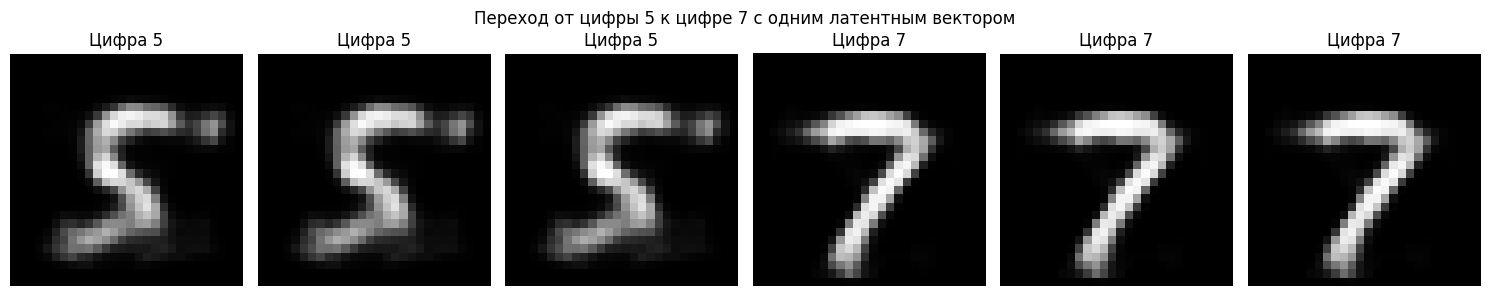

Переход от цифры 1 к цифре 8:


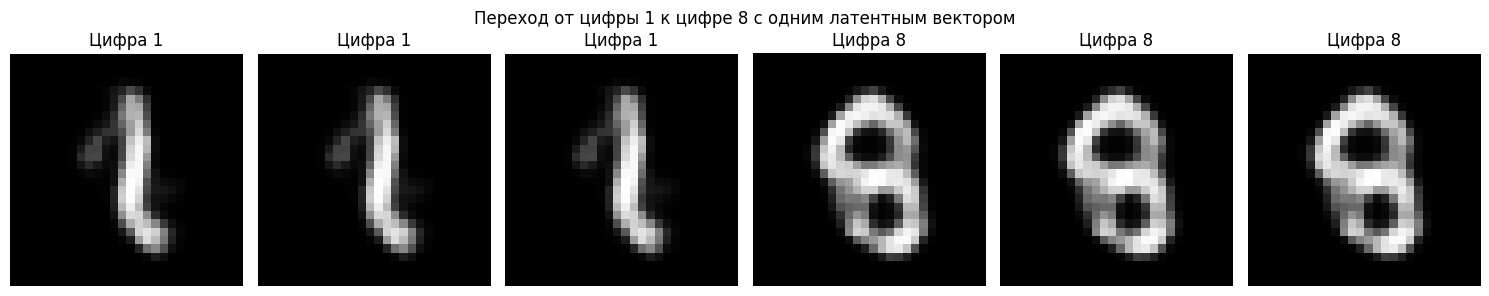

Переход от цифры 0 к цифре 9:


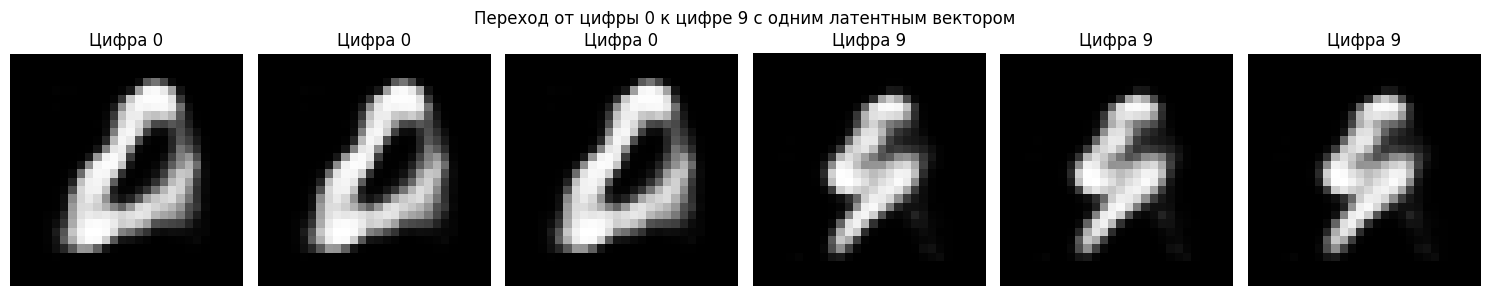

In [54]:
# Функция для интерполяции между двумя разными цифрами
def interpolate_between_digits(model, digit1, digit2, num_steps=8, device=None):
    """
    Интерполирует между двумя разными цифрами, используя один латентный вектор

    Args:
        model: обученная модель CVAE
        digit1: первая цифра
        digit2: вторая цифра
        num_steps: количество шагов интерполяции
        device: устройство для вычислений
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    # Генерируем латентный вектор
    z = torch.randn(1, model.latent_dim, device=device)

    # Создаем интерполяции
    interpolations = []

    # Создаем one-hot векторы для цифр
    one_hot1 = torch.zeros(1, model.num_classes, device=device)
    one_hot1[0, digit1] = 1

    one_hot2 = torch.zeros(1, model.num_classes, device=device)
    one_hot2[0, digit2] = 1

    # Для каждого шага интерполяции
    for alpha in np.linspace(0, 1, num_steps):
        # Интерполируем one-hot векторы
        interp_one_hot = one_hot1 * (1 - alpha) + one_hot2 * alpha

        # Получаем индекс наибольшего значения (для визуализации)
        digit_idx = torch.argmax(interp_one_hot, dim=1)

        # Генерируем изображение
        # Нужно модифицировать decoder для работы с не-one-hot входами,
        # но это более сложная задача. Для демонстрации просто округлим до ближайшей цифры.
        if alpha < 0.5:
            digit_tensor = torch.tensor([digit1], device=device)
        else:
            digit_tensor = torch.tensor([digit2], device=device)

        with torch.no_grad():
            sample = model.decode(z, digit_tensor)
            interpolations.append(sample)

    # Объединяем результаты
    interpolations = torch.cat(interpolations, dim=0)

    # Визуализируем
    plt.figure(figsize=(15, 3))
    for i in range(num_steps):
        plt.subplot(1, num_steps, i + 1)
        plt.imshow(interpolations[i].cpu().squeeze().numpy(), cmap='gray')
        if i < num_steps // 2:
            plt.title(f"Цифра {digit1}")
        else:
            plt.title(f"Цифра {digit2}")
        plt.axis('off')

    plt.suptitle(f"Переход от цифры {digit1} к цифре {digit2} с одним латентным вектором")
    plt.tight_layout()
    plt.show()

    return interpolations

# Демонстрируем переходы между разными парами цифр
digit_pairs = [(5, 7), (1, 8), (0, 9)]

for digit1, digit2 in digit_pairs:
    print(f"Переход от цифры {digit1} к цифре {digit2}:")
    interpolate_between_digits(cvae, digit1, digit2, num_steps=6, device=device)

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

Сравнение латентных пространств CVAE и VAE:
Применяем t-SNE для снижения размерности...


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


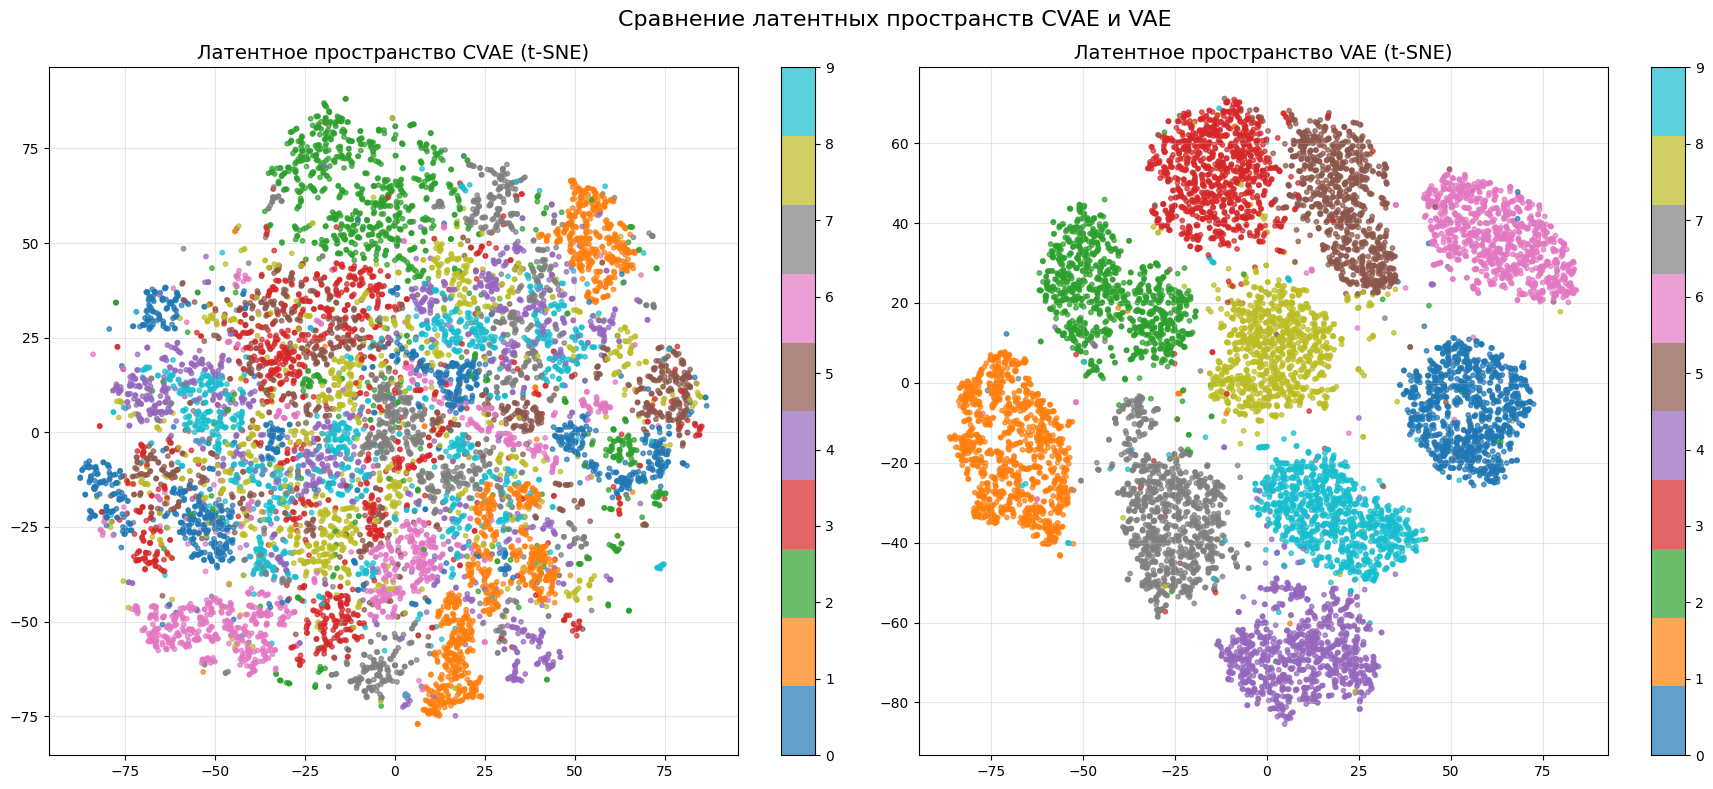

In [56]:
# Визуализация латентного пространства CVAE и сравнение с VAE
def visualize_cvae_latent_space(cvae_model, vae_model, data_loader, device=None):
    """
    Визуализирует и сравнивает латентные пространства CVAE и VAE

    Args:
        cvae_model: обученная модель CVAE
        vae_model: обученная модель VAE
        data_loader: загрузчик данных
        device: устройство для вычислений
    """
    if device is None:
        device = next(cvae_model.parameters()).device

    # Переключаем модели в режим оценки
    cvae_model.eval()
    vae_model.eval()

    # Списки для сохранения латентных векторов и меток
    cvae_latent_vectors = []
    vae_latent_vectors = []
    labels = []

    # Проходим по тестовому датасету и получаем латентные векторы
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)

            # Получаем латентные векторы для CVAE
            cvae_mu, _, _ = cvae_model.encode(data, target)

            # Получаем латентные векторы для VAE
            vae_mu, _ = vae_model.encode(data)

            # Сохраняем латентные векторы и метки
            cvae_latent_vectors.append(cvae_mu.cpu().numpy())
            vae_latent_vectors.append(vae_mu.cpu().numpy())
            labels.append(target.cpu().numpy())

    # Объединяем данные из всех батчей
    cvae_latent_vectors = np.vstack(cvae_latent_vectors)
    vae_latent_vectors = np.vstack(vae_latent_vectors)
    labels = np.concatenate(labels)

    # Применяем t-SNE для снижения размерности до 2D
    print("Применяем t-SNE для снижения размерности...")
    from sklearn.manifold import TSNE

    # Создаем и настраиваем t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)

    # Применяем t-SNE к латентным пространствам
    cvae_latent_2d = tsne.fit_transform(cvae_latent_vectors)

    # Создаем новый экземпляр t-SNE для VAE (чтобы избежать влияния результатов CVAE)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    vae_latent_2d = tsne.fit_transform(vae_latent_vectors)

    # Создаем подграфики для сравнения
    plt.figure(figsize=(18, 8))

    # Визуализируем латентное пространство CVAE
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(cvae_latent_2d[:, 0], cvae_latent_2d[:, 1],
                         c=labels, cmap='tab10', alpha=0.7, s=10)

    plt.colorbar(scatter, ticks=range(10))
    plt.title('Латентное пространство CVAE (t-SNE)', fontsize=14)
    plt.grid(True, alpha=0.3)

    # Визуализируем латентное пространство VAE
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(vae_latent_2d[:, 0], vae_latent_2d[:, 1],
                         c=labels, cmap='tab10', alpha=0.7, s=10)

    plt.colorbar(scatter, ticks=range(10))
    plt.title('Латентное пространство VAE (t-SNE)', fontsize=14)
    plt.grid(True, alpha=0.3)

    plt.suptitle('Сравнение латентных пространств CVAE и VAE', fontsize=16)
    plt.tight_layout()
    plt.show()

    return cvae_latent_2d, vae_latent_2d, labels

# Визуализируем и сравниваем латентные пространства
print("Сравнение латентных пространств CVAE и VAE:")
cvae_latent, vae_latent, labels = visualize_cvae_latent_space(cvae, autoencoder, test_loader, device)

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

1. Степень кластеризации по классам:

В обычном VAE классы разделяются естественным образом, так как модель должна кодировать всю информацию об изображении (включая класс) в латентном пространстве
В CVAE классы могут быть более смешанными, так как информация о классе передается отдельно. Латентное пространство CVAE кодирует более "стилистические" аспекты изображений, а не их класс


2. Перекрытие кластеров:

В VAE кластеры разных цифр обычно имеют меньше перекрытий
В CVAE кластеры могут сильнее перекрываться, так как латентное представление фокусируется на других аспектах изображения


3. Структура внутри кластеров:

В CVAE внутренняя структура кластеров может быть более выраженной, так как модель может использовать латентное пространство для кодирования вариаций стиля в пределах одного класса
В обычном VAE внутренняя структура кластеров может быть менее выраженной, так как модель должна использовать латентное пространство для кодирования и класса, и стиля


4. Общее распределение:

CVAE может иметь более равномерное распределение в латентном пространстве, так как разные классы могут использовать одни и те же области
VAE может иметь более выраженные области для разных классов



Эти различия показывают, что CVAE действительно "разгружает" латентное пространство от необходимости кодировать класс изображения, позволяя использовать его более эффективно для кодирования других аспектов изображения, таких как стиль написания, толщина линий, наклон и так далее.